# 14 · PatDNN end-to-end on Student-120

**Pattern + connectivity pruning → masked recovery → full INT8 → Layerwise Representation →
filter/kernel reorder → FKW storage → load-reuse code generation → auto-tuning → ESP32 evidence**

This notebook is a from-first-principles reproduction and TinyML adaptation of Niu *et al.*,
*PatDNN: Achieving Real-Time DNN Execution on Mobile Devices with Pattern-based Weight Pruning*
(ASPLOS 2020). It follows the complete two-stage paper pipeline. It does **not** equate zeros in a
dense TFLite model with sparse acceleration.

Read the registered protocol before running:
[`PATDNN_IMPLEMENTATION_PLAN.md`](PATDNN_IMPLEMENTATION_PLAN.md).


## Notebook map and evidence boundary

```text
Frozen Student-120 + data contract
                 │
                 ▼
Natural patterns ──► P={6,8,12}
                 │
                 ▼
Joint ADMM: (Z,U) pattern + (Y,V) connectivity
                 │
                 ▼
Fixed mapping + masked recovery + validation selection
                 │
                 ▼
Full-INT8 quality control ──► held-out test once
                 │
                 ▼
LR ──► FKR ──► five-array FKW ──► LRE codegen ──► autotune
                 │
                 ▼
Host parity ──► ESP32-CAM / ESP32-S3 physical ablation
```

The notebook labels results as **theoretical**, **host measured**, or **physical-device measured**.
Missing device captures remain missing; they are never replaced with predicted speedups.


## Paper fidelity: the full optimization problem

PatDNN jointly constrains every selected convolution tensor with a pattern set and a maximum
number of non-empty channel connections:

```math
\min_{\{W_k\},\{b_k\}}
f\!\left(\{W_k\}_{k=1}^{N},\{b_k\}_{k=1}^{N}\right)
\quad\text{s.t.}\quad
W_k\in\mathcal{S}_k,\; W_k\in\mathcal{S}'_k.
```

With pattern auxiliary/dual variables `(Z,U)` and connectivity variables `(Y,V)`, the weight
subproblem is:

```math
\mathcal{L}_{W}=f(W,b)
+\sum_k\frac{\rho_{p,k}}{2}\|W_k-Z_k+U_k\|_F^2
+\sum_k\frac{\rho_{c,k}}{2}\|W_k-Y_k+V_k\|_F^2.
```

The previous experiment had only the first quadratic term. This notebook implements both.


## 1 · Locate the repository


In [84]:
from pathlib import Path

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists(), f"Repository root not found from {Path.cwd()}"
print(ROOT)


/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32


## 2 · Imports and deterministic runtime


In [85]:
import gzip
import hashlib
import json
import math
import os
import platform
import random
import subprocess
import time
from collections import Counter, defaultdict
from dataclasses import asdict, dataclass
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import yaml
from IPython.display import Markdown, display
from sklearn.metrics import ConfusionMatrixDisplay

from vww_esp32.evaluation import classification_metrics, expected_calibration_error, select_threshold
from vww_esp32.exporting import convert_full_integer, inspect_tflite
from vww_esp32.profiling import profile_model

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception as exc:
    print("Deterministic kernels unavailable:", exc)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 160)
print({"python": platform.python_version(), "tensorflow": tf.__version__,
       "devices": [d.device_type for d in tf.config.list_physical_devices()]})


{'python': '3.10.13', 'tensorflow': '2.20.0', 'devices': ['CPU']}


## 3 · Pre-register the experiment

`RUN_TRAINING=0` permits a fast audit of the baseline, pattern vocabulary, topology, and codegen
logic. Set `PATDNN_RUN_TRAINING=1` for the registered ADMM matrix. Existing checkpoints are reused
only when their manifests and hashes match.

The paper tests 6, 8, and 12 patterns and uses 8 as its preferred trade-off. Connectivity keep
ratios include the paper-like `1/3.6 ≈ 0.278`, but gentler ratios are included because this network
is dramatically smaller than VGG/ResNet. The first convolution remains unpruned, following the
paper's sensitivity exception.


In [86]:
CONFIG_PATH = ROOT / "configs/distillation_response_kd_alignment_120.yaml"
FLOAT_MODEL_PATH = ROOT / "artifacts/distillation/response_kd_alignment_student_120/models/same_view_lambda0.keras"
REFERENCE_INT8_PATH = ROOT / "artifacts/distillation/qkd_int8_student_120/models/student_120_champion_ptq_int8.tflite"
MANIFEST_PATH = ROOT / "data/processed/manifest.csv"
PAPER_PATH = ROOT / "papers/pruning/2001.00138v4.pdf"

OUTPUT_DIR = ROOT / "artifacts/pruning/patdnn_student_120"
MODEL_DIR = OUTPUT_DIR / "models"
REPORT_DIR = OUTPUT_DIR / "reports"
FIGURE_DIR = OUTPUT_DIR / "figures"
STATE_DIR = OUTPUT_DIR / "state"
LR_DIR = OUTPUT_DIR / "lr"
FKW_DIR = OUTPUT_DIR / "fkw"
GENERATED_DIR = OUTPUT_DIR / "generated"
for directory in (MODEL_DIR, REPORT_DIR, FIGURE_DIR, STATE_DIR, LR_DIR, FKW_DIR, GENERATED_DIR):
    directory.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = (120, 120)
TEACHER_VIEW_SIZE = (160, 160)
BATCH_SIZE = 32
PATTERN_ENTRIES = 4
PATTERN_LIBRARY_SIZES = (6, 8, 12)
CONNECTIVITY_KEEP_RATIOS = (0.75, 0.50, 1.0 / 3.6)
ADMM_ITERATIONS = 6
ADMM_EPOCHS_PER_ITERATION = 1
ADMM_LEARNING_RATE = 1e-5
RECOVERY_MAX_EPOCHS = 6
RECOVERY_PATIENCE = 2
RECOVERY_LEARNING_RATE = 1e-5
LABEL_SMOOTHING = 0.03
RHO_PATTERN_CANDIDATES = (1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2)
RHO_CONNECTIVITY_CANDIDATES = RHO_PATTERN_CANDIDATES
TARGET_PENALTY_TO_TASK_GRADIENT_RATIO = 0.05
REPRESENTATIVE_SAMPLES = 500
MINIMUM_RECALL = 0.80
MAXIMUM_F1_DROP = 0.03
# RUN_TRAINING = os.environ.get("PATDNN_RUN_TRAINING", "0") == "1"
RUN_TRAINING = os.environ.get("PATDNN_RUN_TRAINING", "1") == "1"
REUSE_CHECKPOINTS = os.environ.get("PATDNN_REUSE_CHECKPOINTS", "1") == "1"
RUN_DEVICE_AUTOTUNE = os.environ.get("PATDNN_RUN_DEVICE_AUTOTUNE", "0") == "1"

required = [CONFIG_PATH, FLOAT_MODEL_PATH, REFERENCE_INT8_PATH, MANIFEST_PATH, PAPER_PATH]
missing = [str(path.relative_to(ROOT)) for path in required if not path.exists()]
assert not missing, f"Missing required inputs: {missing}"
print({"run_training": RUN_TRAINING, "reuse": REUSE_CHECKPOINTS,
       "pattern_counts": PATTERN_LIBRARY_SIZES, "connectivity_keep": CONNECTIVITY_KEEP_RATIOS})


{'run_training': True, 'reuse': True, 'pattern_counts': (6, 8, 12), 'connectivity_keep': (0.75, 0.5, 0.2777777777777778)}


## 4 · Freeze all upstream artifacts


In [87]:
def sha256_file(path: Path, chunk_bytes: int = 1 << 20) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_bytes), b""):
            digest.update(chunk)
    return digest.hexdigest()


frozen_hashes = {str(path.relative_to(ROOT)): sha256_file(path) for path in required}
expected_hashes = {
    str(FLOAT_MODEL_PATH.relative_to(ROOT)): "88e98014baab353bb6eb6df9280e4f993de34adf75dcb9546c8ba99047349845",
    str(REFERENCE_INT8_PATH.relative_to(ROOT)): "8350c8f62a02e19c353485994c04ed6926b5e6a446f04861a02deb424c830756",
}
for artifact, expected in expected_hashes.items():
    assert frozen_hashes[artifact] == expected, f"Frozen artifact changed: {artifact}"
display(pd.DataFrame([{"artifact": k, "sha256": v} for k, v in frozen_hashes.items()]).style.hide(axis="index"))


artifact,sha256
configs/distillation_response_kd_alignment_120.yaml,73b027bfc4d7589b7e1f7ef476c8fcc1f9fa4628b33fb3af0243a9e416da37a8
artifacts/distillation/response_kd_alignment_student_120/models/same_view_lambda0.keras,88e98014baab353bb6eb6df9280e4f993de34adf75dcb9546c8ba99047349845
artifacts/distillation/qkd_int8_student_120/models/student_120_champion_ptq_int8.tflite,8350c8f62a02e19c353485994c04ed6926b5e6a446f04861a02deb424c830756
data/processed/manifest.csv,6e25ac1d8c6b98ccc54f188e7d38ce34c9c711d1bc2242f15517680652e38704
papers/pruning/2001.00138v4.pdf,30457aee7d3c1742da21d363548cf6cbb092ff99058656ae04bb24ac1ccd3035


## 5 · Load and statically profile Student-120


In [88]:
baseline_model = tf.keras.models.load_model(FLOAT_MODEL_PATH, compile=False)

In [89]:
baseline_layers, baseline_liveness, baseline_summary = profile_model(
    baseline_model, 
    batch_size=1, 
    training_batch_size=BATCH_SIZE
)

In [90]:
assert baseline_model.input_shape == (None, 120, 120, 3)
assert baseline_model.output_shape == (None, 1)
assert baseline_model.count_params() == 218_801
assert int(baseline_summary["estimated_macs_batch1"]) == 10_487_648
baseline_layers.to_csv(REPORT_DIR / "baseline_layer_profile.csv", index=False)
baseline_liveness.to_csv(REPORT_DIR / "baseline_activation_liveness.csv", index=False)
(REPORT_DIR / "baseline_static_profile.json").write_text(json.dumps(baseline_summary, indent=2) + "\n")
display(pd.DataFrame([{
    "input": str(baseline_model.input_shape), "parameters": baseline_model.count_params(),
    "dense_macs": int(baseline_summary["estimated_macs_batch1"]),
    "int8_live_activation_peak": int(baseline_summary["peak_live_activation_int8_bytes_batch1_hypothetical"]),
}]).style.hide(axis="index"))


input,parameters,dense_macs,int8_live_activation_peak
"(None, 120, 120, 3)",218801,10487648,117136


## 6 · Reproduce the exact camera/data geometry

Training uses the same RGB camera augmentation and shared 160-pixel view as the Student-120
response-KD experiment, then downsamples to 120. Evaluation letterboxes directly to 120. This
avoids changing preprocessing while claiming to study pruning.



### 6.1 · Load and validate the immutable data contract

Pruning must not silently change the examples, labels, or split boundaries used by Student-120.
This block validates the manifest before constructing a `tf.data` pipeline. The held-out test
split is created here but remains unopened until full-INT8 model selection.


In [91]:

with CONFIG_PATH.open(encoding="utf-8") as handle:
    source_config = yaml.safe_load(handle)

manifest = pd.read_csv(MANIFEST_PATH)
required_columns = {"image_path", "label", "split", "downloaded", "sha256"}
missing_columns = required_columns.difference(manifest.columns)
assert not missing_columns, f"Manifest columns missing: {sorted(missing_columns)}"
assert set(manifest["split"].unique()) == {"train", "val", "test"}
assert set(manifest["label"].unique()).issubset({0, 1})
assert manifest["image_path"].notna().all()
assert manifest["sha256"].notna().all()
assert manifest["downloaded"].astype(bool).all(), "Manifest contains images not downloaded"

splits = {
    name: manifest.loc[manifest["split"] == name].reset_index(drop=True)
    for name in ("train", "val", "test")
}
assert all(len(frame) for frame in splits.values())
for left, right in (("train", "val"), ("train", "test"), ("val", "test")):
    overlap = set(splits[left]["sha256"]).intersection(splits[right]["sha256"])
    assert not overlap, f"Data leakage between {left} and {right}: {len(overlap)} duplicate hashes"

split_summary = (
    manifest.groupby(["split", "label"], observed=True)
    .size().rename("images").reset_index()
    .assign(class_name=lambda frame: frame["label"].map({0: "no person", 1: "person"}))
)
display(split_summary[["split", "class_name", "images"]].style.hide(axis="index"))
print({name: len(frame) for name, frame in splits.items()})


split,class_name,images
test,no person,1019
test,person,981
train,no person,6000
train,person,6000
val,no person,1011
val,person,989


{'train': 12000, 'val': 2000, 'test': 2000}



### 6.2 · Decode RGB and preserve aspect ratio

`decode_rgb` always returns three channels in the camera-compatible `[0,255]` float domain.
`resize_with_pad` performs the same aspect-ratio-preserving letterbox used by the Student-120
experiment. It does not stretch a person to fill a square.


In [92]:
AUTOTUNE = tf.data.AUTOTUNE

In [93]:
def decode_rgb(path):
    encoded = tf.io.read_file(path)
    image = tf.io.decode_image(encoded, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    return tf.cast(image, tf.float32)


def letterbox(image, size):
    image = tf.image.resize_with_pad(
        image,
        target_height=int(size[0]),
        target_width=int(size[1]),
        method="bilinear",
        antialias=True,
    )
    image.set_shape([int(size[0]), int(size[1]), 3])
    return image



### 6.3 · Rebuild the frozen RGB camera augmentation

The augmentation operates in `[0,1]`, where its brightness, saturation, contrast, and sensor-noise
parameters were originally calibrated. The result is clipped before conversion back to the
Student model's `[0,255]` input domain. No grayscale conversion is applied.


In [94]:

def build_shared_augmentation(seed=SEED):
    augmentation = source_config["augmentation"]
    return tf.keras.Sequential(
        [
            tf.keras.layers.RandomFlip("horizontal", seed=seed),
            tf.keras.layers.RandomTranslation(
                augmentation["translation_fraction"],
                augmentation["translation_fraction"],
                fill_mode="reflect",
                seed=seed + 1,
            ),
            tf.keras.layers.RandomBrightness(
                augmentation["brightness_delta"],
                value_range=(0.0, 1.0),
                seed=seed + 2,
            ),
            tf.keras.layers.RandomContrast(
                augmentation["contrast_factor"],
                seed=seed + 3,
            ),
            tf.keras.layers.RandomSaturation(
                (
                    1.0 - augmentation["saturation_factor"],
                    1.0 + augmentation["saturation_factor"],
                ),
                value_range=(0.0, 1.0),
                seed=seed + 4,
            ),
            tf.keras.layers.GaussianNoise(
                augmentation["sensor_noise_stddev"],
                seed=seed + 5,
            ),
        ],
        name=f"shared_camera_augmentation_{seed}",
    )



### 6.4 · Construct the training pipeline

Training first letterboxes to the shared 160×160 view used by the distillation experiment,
applies the RGB camera augmentation, then downsamples once to 120×120. Seeds are derived from the
candidate and ADMM iteration, while every individual pipeline remains deterministic.


In [95]:

def make_training_dataset(frame, seed=SEED):
    augmentation = build_shared_augmentation(seed)
    paths = frame["image_path"].astype(str).to_numpy()
    labels = frame["label"].astype("float32").to_numpy()
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    options = tf.data.Options()
    options.experimental_deterministic = True
    dataset = dataset.with_options(options)
    dataset = dataset.shuffle(
        buffer_size=min(len(frame), 4096),
        seed=seed,
        reshuffle_each_iteration=True,
    )

    def prepare(path, label):
        shared_view = letterbox(decode_rgb(path), TEACHER_VIEW_SIZE) / 255.0
        shared_view = tf.clip_by_value(shared_view, 0.0, 1.0)
        shared_view = augmentation(shared_view, training=True)
        shared_view = tf.clip_by_value(shared_view, 0.0, 1.0)
        student_view = tf.image.resize(
            shared_view,
            IMAGE_SIZE,
            method="bilinear",
            antialias=True,
        ) * 255.0
        student_view = tf.ensure_shape(student_view, [*IMAGE_SIZE, 3])
        return student_view, tf.reshape(label, (1,))

    return (
        dataset.map(prepare, num_parallel_calls=AUTOTUNE, deterministic=True)
        .batch(BATCH_SIZE, drop_remainder=False)
        .prefetch(AUTOTUNE)
    )



### 6.5 · Construct deterministic validation and test pipelines

Validation and test images receive no random augmentation. They are decoded as RGB and directly
letterboxed to 120×120, exactly matching the deployment preprocessing contract. Shuffling is
disabled so predictions remain aligned with labels and error slices.


In [96]:

def make_eval_dataset(frame, batch_size=BATCH_SIZE):
    paths = frame["image_path"].astype(str).to_numpy()
    labels = frame["label"].astype("float32").to_numpy()
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    options = tf.data.Options()
    options.experimental_deterministic = True
    dataset = dataset.with_options(options)

    def prepare(path, label):
        image = letterbox(decode_rgb(path), IMAGE_SIZE)
        return image, tf.reshape(label, (1,))

    return (
        dataset.map(prepare, num_parallel_calls=AUTOTUNE, deterministic=True)
        .batch(batch_size, drop_remainder=False)
        .prefetch(AUTOTUNE)
    )



### 6.6 · Instantiate datasets and audit the model-input contract

This final block fails early if images become grayscale, use the wrong resolution, leave the
expected pixel range, or produce malformed labels. It also records the split sizes used by every
later experiment branch.


In [97]:
train_ds = make_training_dataset(splits["train"], seed=SEED)
val_ds = make_eval_dataset(splits["val"])
test_ds = make_eval_dataset(splits["test"])

train_images, train_labels = next(iter(train_ds))
val_images, val_labels_audit = next(iter(val_ds))

assert train_images.shape[1:] == (120, 120, 3)
assert val_images.shape[1:] == (120, 120, 3)
assert train_labels.shape[-1] == 1 and val_labels_audit.shape[-1] == 1
assert train_images.dtype == tf.float32 and val_images.dtype == tf.float32
INTERPOLATION_EPSILON = 1e-2  # antialiased resize may overshoot the nominal [0,255] range by float roundoff
assert float(tf.reduce_min(train_images)) >= -INTERPOLATION_EPSILON
assert float(tf.reduce_max(train_images)) <= 255.0 + INTERPOLATION_EPSILON
assert float(tf.reduce_min(val_images)) >= -INTERPOLATION_EPSILON
assert float(tf.reduce_max(val_images)) <= 255.0 + INTERPOLATION_EPSILON

dataset_contract = pd.DataFrame(
    [
        {
            "pipeline": "train",
            "images": len(splits["train"]),
            "batch_shape": str(tuple(train_images.shape)),
            "dtype": train_images.dtype.name,
            "minimum": float(tf.reduce_min(train_images)),
            "maximum": float(tf.reduce_max(train_images)),
            "random_augmentation": True,
        },
        {
            "pipeline": "validation",
            "images": len(splits["val"]),
            "batch_shape": str(tuple(val_images.shape)),
            "dtype": val_images.dtype.name,
            "minimum": float(tf.reduce_min(val_images)),
            "maximum": float(tf.reduce_max(val_images)),
            "random_augmentation": False,
        },
        {
            "pipeline": "held-out test",
            "images": len(splits["test"]),
            "batch_shape": "not iterated before final selection",
            "dtype": "float32",
            "minimum": np.nan,
            "maximum": np.nan,
            "random_augmentation": False,
        },
    ]
)
dataset_contract.to_csv(REPORT_DIR / "dataset_pipeline_contract.csv", index=False)
display(dataset_contract.style.hide(axis="index").format({"minimum": "{:.2f}", "maximum": "{:.2f}"}, na_rep="closed"))


pipeline,images,batch_shape,dtype,minimum,maximum,random_augmentation
train,12000,"(32, 120, 120, 3)",float32,0.00,255.00,True
validation,2000,"(32, 120, 120, 3)",float32,0.00,255.00,False
held-out test,2000,not iterated before final selection,float32,closed,closed,False


## 7 · Quality metrics and validation-only threshold selection


In [98]:
def collect_predictions(model, dataset):
    labels = np.concatenate([np.asarray(y).reshape(-1) for _, y in dataset]).astype(int)
    probabilities = np.asarray(model.predict(dataset, verbose=0)).reshape(-1)
    assert len(labels) == len(probabilities)
    assert np.isfinite(probabilities).all(), "Model produced non-finite probabilities"
    return labels, probabilities

In [99]:
def evaluate_validation(labels, probabilities):
    chosen = select_threshold(
        labels,
        probabilities,
        objective="f1",
        minimum_recall=MINIMUM_RECALL,
        false_positive_cost=1.0,
        false_negative_cost=2.0,
    )
    metrics = classification_metrics(labels, probabilities, chosen["threshold"])
    metrics["ece_10"] = expected_calibration_error(labels, probabilities, bins=10)
    return metrics

In [100]:
val_labels, baseline_val_probabilities = collect_predictions(baseline_model, val_ds)
baseline_val_metrics = evaluate_validation(val_labels, baseline_val_probabilities)
assert len(val_labels) == len(splits["val"])
assert set(np.unique(val_labels)).issubset({0, 1})

baseline_validation_record = {
    key: baseline_val_metrics[key]
    for key in (
        "threshold", "accuracy", "precision", "recall", "specificity",
        "f1", "roc_auc", "pr_auc", "ece_10",
    )
}
(REPORT_DIR / "baseline_validation_metrics.json").write_text(
    json.dumps(baseline_validation_record, indent=2) + "\n"
)
print({"baseline_validation": baseline_validation_record})
print("Held-out test remains closed until full-INT8 candidate selection.")

{'baseline_validation': {'threshold': 0.385, 'accuracy': 0.78, 'precision': 0.7652173913043478, 'recall': 0.8008088978766431, 'specificity': 0.7596439169139466, 'f1': 0.782608695652174, 'roc_auc': 0.8573827433119408, 'pr_auc': 0.8605503657864055, 'ece_10': 0.033375023633241664}}
Held-out test remains closed until full-INT8 candidate selection.


# Part I · Understand the available pruning units

For a standard convolution `W[kh,kw,Cin,Cout]`, one connectivity unit is a complete spatial
kernel `W[:,:,i,j]`. For depthwise convolution `W[kh,kw,Cin,m]`, it is
`W[:,:,i,m]`. Pattern projection applies only to 3×3 kernels; connectivity projection applies to
all convolution kernels, including 1×1 pointwise connections.


In [101]:
CONV_TYPES = (
    tf.keras.layers.Conv2D, 
    tf.keras.layers.DepthwiseConv2D
)

In [102]:
def convolution_layers(model):
    return [layer for layer in model.layers if isinstance(layer, CONV_TYPES)]

In [103]:
def pattern_layers(model):
    return [layer for layer in convolution_layers(model) if tuple(layer.kernel_size) == (3, 3)]

In [104]:
def iter_kernels(layer, tensor=None):
    values = np.asarray(layer.kernel.numpy() if tensor is None else tensor)
    for axis_0 in range(values.shape[2]):
        for axis_1 in range(values.shape[3]):
            yield (axis_0, axis_1), values[:, :, axis_0, axis_1]

In [105]:
# add index pruning pattern
def put_kernel(tensor, index, value):
    tensor[:, :, index[0], index[1]] = value

In [106]:
first_conv_name = convolution_layers(baseline_model)[0].name
inventory = []
profile_by_name = baseline_layers.set_index("layer_name")
for layer in convolution_layers(baseline_model):
    kernels = layer.kernel.shape[2] * layer.kernel.shape[3]
    inventory.append({
        "layer": layer.name, "type": layer.__class__.__name__, "kernel": "×".join(map(str, layer.kernel.shape)),
        "spatial": f"{layer.kernel_size[0]}×{layer.kernel_size[1]}", "connections": int(kernels),
        "pattern_eligible": tuple(layer.kernel_size) == (3, 3), "connectivity_eligible": layer.name != first_conv_name,
        "dense_macs": int(profile_by_name.loc[layer.name, "estimated_macs_batch1"]),
    })
conv_inventory = pd.DataFrame(inventory)
conv_inventory.to_csv(REPORT_DIR / "convolution_pruning_inventory.csv", index=False)
display(conv_inventory.style.hide(axis="index").format({"dense_macs": "{:,}"}))

layer,type,kernel,spatial,connections,pattern_eligible,connectivity_eligible,dense_macs
conv1,Conv2D,3×3×3×8,3×3,24,True,False,"777,600"
conv_dw_1,DepthwiseConv2D,3×3×8×1,3×3,8,True,True,"259,200"
conv_pw_1,Conv2D,1×1×8×16,1×1,128,False,True,"460,800"
conv_dw_2,DepthwiseConv2D,3×3×16×1,3×3,16,True,True,"129,600"
conv_pw_2,Conv2D,1×1×16×32,1×1,512,False,True,"460,800"
conv_dw_3,DepthwiseConv2D,3×3×32×1,3×3,32,True,True,"259,200"
conv_pw_3,Conv2D,1×1×32×32,1×1,1024,False,True,"921,600"
conv_dw_4,DepthwiseConv2D,3×3×32×1,3×3,32,True,True,"64,800"
conv_pw_4,Conv2D,1×1×32×64,1×1,2048,False,True,"460,800"
conv_dw_5,DepthwiseConv2D,3×3×64×1,3×3,64,True,True,"129,600"


## 8 · Visualize where Student-120 spends computation


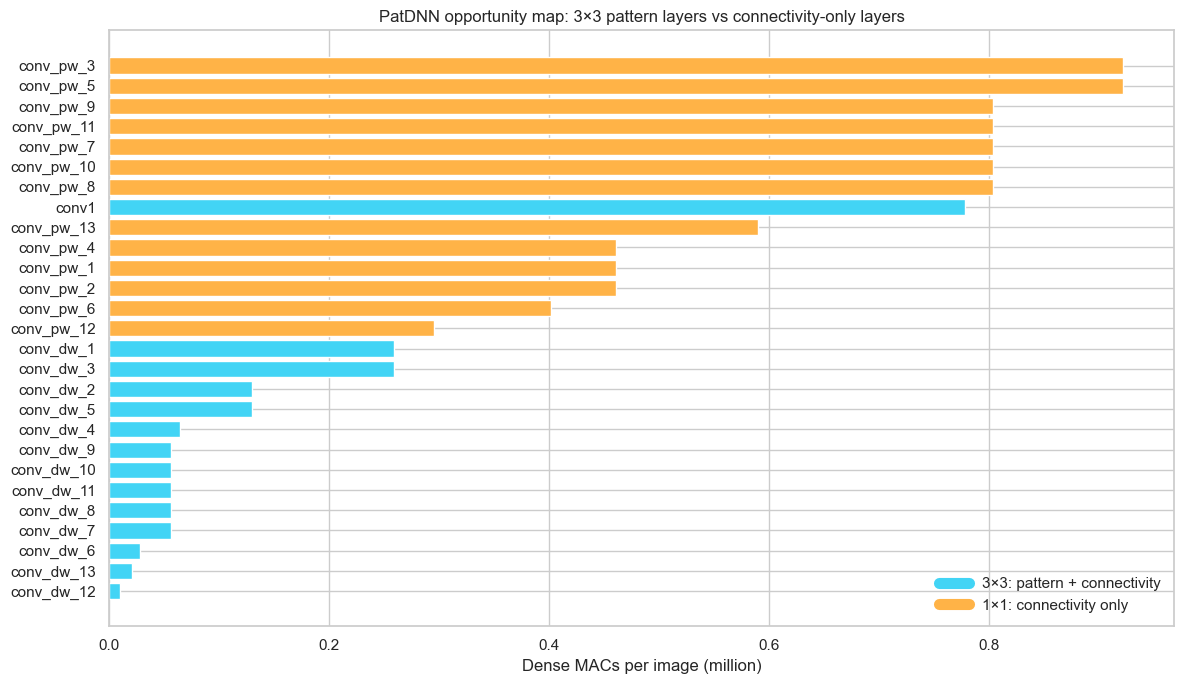

{'3x3_pattern_eligible_mac_share': '18.70%', 'warning': 'pattern-only speedup is bounded by this share before overhead'}


In [107]:
plot_inventory = conv_inventory.sort_values("dense_macs")
colors = np.where(plot_inventory.pattern_eligible, "#42d4f5", "#ffb347")
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(plot_inventory.layer, plot_inventory.dense_macs / 1e6, color=colors)
ax.set(xlabel="Dense MACs per image (million)", title="PatDNN opportunity map: 3×3 pattern layers vs connectivity-only layers")
ax.legend(handles=[plt.Line2D([0],[0], color="#42d4f5", lw=8, label="3×3: pattern + connectivity"),
                   plt.Line2D([0],[0], color="#ffb347", lw=8, label="1×1: connectivity only")], frameon=False)
fig.tight_layout(); fig.savefig(FIGURE_DIR / "patdnn_opportunity_map.png", dpi=180, bbox_inches="tight"); plt.show()
pattern_mac_share = conv_inventory.loc[conv_inventory.pattern_eligible, "dense_macs"].sum() / baseline_summary["estimated_macs_batch1"]
print({"3x3_pattern_eligible_mac_share": f"{pattern_mac_share:.2%}",
       "warning": "pattern-only speedup is bounded by this share before overhead"})


# Part II · Design the pattern set (§4.1)

Every legal pattern retains the center and three of eight neighbors:

```math
|\mathcal{P}_{all}|=\binom{8}{3}=56,
\qquad \|M_p\|_0=4.
```

The natural pattern for each pretrained kernel is its center plus the three largest-magnitude
neighbors. The global library uses the most frequent natural patterns; ties are resolved by
retained squared energy and then the integer mask code for reproducibility.


In [108]:
CENTER_INDEX = 4

In [109]:
NEIGHBORS = tuple(i for i in range(9) if i != CENTER_INDEX)

In [110]:
def mask_to_code(mask):
    return int(sum(int(bit) << i for i, bit in enumerate(np.asarray(mask, np.uint8).reshape(-1))))

In [111]:
def code_to_mask(code):
    return np.asarray([(code >> i) & 1 for i in range(9)], np.float32).reshape(3, 3)

In [112]:
def natural_mask(kernel):
    magnitude = np.abs(np.asarray(kernel)).reshape(-1)
    neighbors = sorted(NEIGHBORS, key=lambda i: (-magnitude[i], i))[:3]
    flat = np.zeros(9, np.float32); flat[[CENTER_INDEX, *neighbors]] = 1
    return flat.reshape(3, 3)

In [113]:
LEGAL_PATTERN_CODES = []
for chosen in combinations(NEIGHBORS, 3):
    flat = np.zeros(9, np.float32); flat[[CENTER_INDEX, *chosen]] = 1
    LEGAL_PATTERN_CODES.append(mask_to_code(flat))
assert len(set(LEGAL_PATTERN_CODES)) == 56

## 9 · Census natural patterns and retained energy


In [114]:
counts, energy = Counter(), defaultdict(float)
natural_rows = []

In [115]:
for layer in pattern_layers(baseline_model):
    for kernel_id, (index, kernel) in enumerate(iter_kernels(layer)):
        mask = natural_mask(kernel)
        pattern_code = mask_to_code(mask)
        retained = float(np.sum(np.square(kernel) * mask))
        total = float(np.sum(np.square(kernel)))
        counts[pattern_code] += 1
        energy[pattern_code] += retained
        natural_rows.append(
            {
                "layer": layer.name, 
                "kernel_id": kernel_id, 
                "axis_0": index[0], 
                "axis_1": index[1],
                "pattern_code": pattern_code, 
                "retained_energy_fraction": retained / total if total else 1.0
            }
        )

In [116]:
natural_assignments = pd.DataFrame(natural_rows)
pattern_ranking = pd.DataFrame([{"pattern_code": p, "count": n, "retained_l2_energy": energy[p]} for p, n in counts.items()])
pattern_ranking = pattern_ranking.sort_values(["count", "retained_l2_energy", "pattern_code"], ascending=[False, False, True]).reset_index(drop=True)
pattern_ranking.insert(0, "rank", np.arange(1, len(pattern_ranking) + 1))
pattern_ranking["share"] = pattern_ranking["count"] / pattern_ranking["count"].sum()
pattern_ranking["cumulative_share"] = pattern_ranking.share.cumsum()
natural_assignments.to_csv(REPORT_DIR / "natural_pattern_assignments.csv", index=False)
pattern_ranking.to_csv(REPORT_DIR / "natural_pattern_ranking.csv", index=False)
display(pattern_ranking.head(16).style.hide(axis="index").format({"share":"{:.1%}", "cumulative_share":"{:.1%}"}))

rank,pattern_code,count,retained_l2_energy,share,cumulative_share
1,27,190,6972.985583,15.0%,15.0%
2,85,115,767.788206,9.1%,24.1%
3,154,106,3639.090880,8.4%,32.5%
4,58,98,3353.374142,7.8%,40.3%
5,184,57,2689.699441,4.5%,44.8%
6,178,49,2256.193670,3.9%,48.7%
7,147,42,1385.793721,3.3%,52.0%
8,210,39,1204.130008,3.1%,55.1%
9,23,37,941.010377,2.9%,58.0%
10,57,35,1376.181061,2.8%,60.8%


## 10 · Draw the actual discovered vocabulary


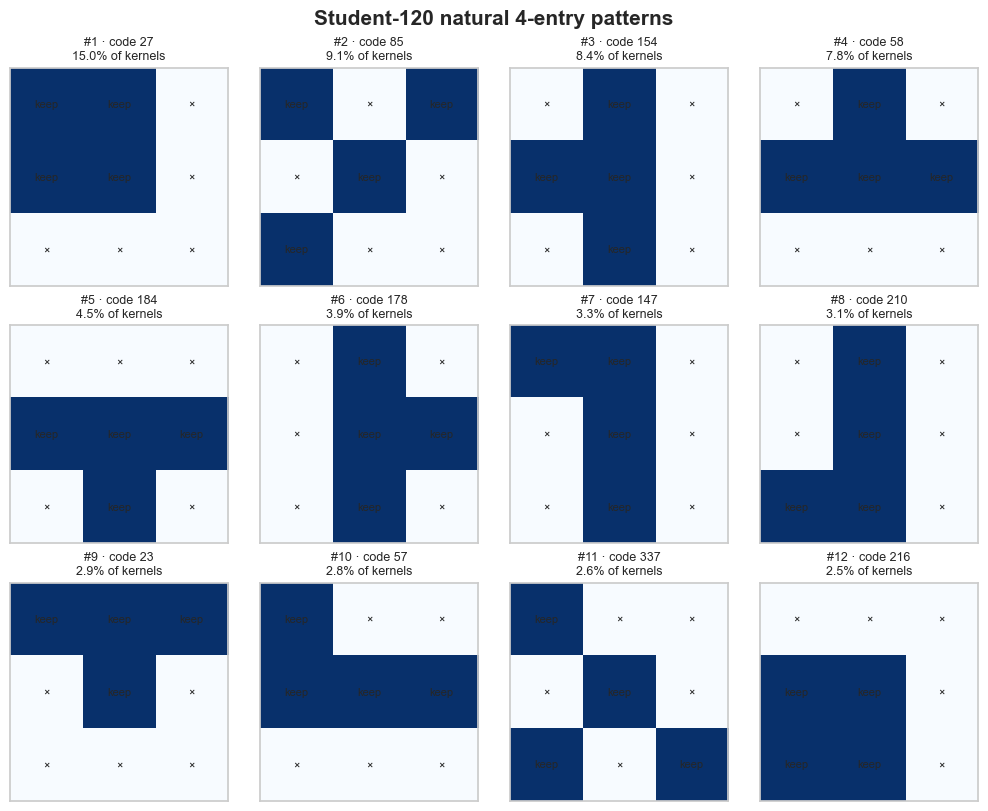

In [117]:
top_codes = pattern_ranking.head(12).pattern_code.astype(int).tolist()
fig, axes = plt.subplots(3, 4, figsize=(10, 8), constrained_layout=True)
for rank, (ax, pattern_code) in enumerate(zip(axes.flat, top_codes), start=1):
    mask = code_to_mask(pattern_code)
    ax.imshow(mask, cmap="Blues", vmin=0, vmax=1)
    for r in range(3):
        for c in range(3): ax.text(c, r, "keep" if mask[r,c] else "×", ha="center", va="center", fontsize=8)
    row = pattern_ranking[pattern_ranking.pattern_code == pattern_code].iloc[0]
    ax.set_title(f"#{rank} · code {pattern_code}\n{row['share']:.1%} of kernels", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Student-120 natural 4-entry patterns", fontsize=15, weight="bold")
fig.savefig(FIGURE_DIR / "natural_pattern_vocabulary.png", dpi=180, bbox_inches="tight"); plt.show()


## 11 · Project a kernel onto a candidate library


In [118]:
def library_codes(size):
    return pattern_ranking.head(size).pattern_code.astype(int).tolist()

In [119]:
def best_pattern(kernel, codes):
    squared = np.square(np.asarray(kernel, dtype=np.float64))  # avoid INT8 overflow during post-quantization packing
    retained = [float(np.sum(squared * code_to_mask(p))) for p in codes]
    best_index = int(np.argmax(retained)); total = float(np.sum(squared))
    return int(codes[best_index]), code_to_mask(codes[best_index]), retained[best_index] / total if total else 1.0

In [120]:
def project_pattern_tensor(layer, value, codes):
    value = np.asarray(value, np.float32)
    projected = np.zeros_like(value)
    masks = np.zeros_like(value)
    rows = []
    for kernel_id, (index, kernel) in enumerate(iter_kernels(layer, value)):

        pattern_code, mask, fraction = best_pattern(kernel, codes)
        
        put_kernel(
            projected, 
            index, 
            kernel * mask
        )
        put_kernel(
            masks, 
            index, 
            mask
        )
        rows.append(
            {
                "layer": layer.name, 
                "kernel_id": kernel_id, 
                "axis_0": index[0], 
                "axis_1": index[1],
                "pattern_code": pattern_code, 
                "retained_energy_fraction": fraction
            }
        )
    return projected, masks, pd.DataFrame(rows)

In [121]:
coverage_rows = []
for size in PATTERN_LIBRARY_SIZES:
    fractions = []
    for layer in pattern_layers(baseline_model):
        for _, kernel in iter_kernels(layer): fractions.append(best_pattern(kernel, library_codes(size))[2])
    coverage_rows.append(
        {
            "patterns": size,
            "exact_natural_coverage": natural_assignments.pattern_code.isin(library_codes(size)).mean(),
            "mean_projected_energy": np.mean(fractions), 
            "p05_projected_energy": np.percentile(fractions, 5),
            "pattern_id_bits": math.ceil(math.log2(size))
        }
    )
library_coverage = pd.DataFrame(coverage_rows)
library_coverage.to_csv(REPORT_DIR / "pattern_library_coverage.csv", index=False)
display(library_coverage.style.hide(axis="index").format({"exact_natural_coverage":"{:.1%}", "mean_projected_energy":"{:.1%}", "p05_projected_energy":"{:.1%}"}))

patterns,exact_natural_coverage,mean_projected_energy,p05_projected_energy,pattern_id_bits
6,48.7%,78.7%,49.5%,3
8,55.1%,79.5%,50.0%,3
12,65.9%,80.8%,51.9%,4


# Part III · Connectivity pruning (§4.2)

Connectivity pruning removes whole channel-to-filter kernels. Projection keeps the `α_k` kernels
with largest L2 norm:

```math
Y_k=\Pi_{\alpha_k}(W_k+V_k).
```

The first convolution is protected. The notebook reports achieved counts instead of assuming
that a requested ratio is exactly representable in small layers.


In [122]:
def project_connectivity_tensor(
        layer, 
        value, 
        keep_ratio, 
        protected=False
):
    value = np.asarray(value, np.float32)
    items = [(index, kernel, float(np.linalg.norm(kernel))) for index, kernel in iter_kernels(layer, value)]

    keep_count = len(items) if protected else max(1, int(math.ceil(len(items) * keep_ratio)))

    order = sorted(range(len(items)), key=lambda i: (-items[i][2], items[i][0]))

    keep_ids = set(order[:keep_count])

    projected = np.zeros_like(value)
    masks = np.zeros_like(value)
    
    rows = []
    for kernel_id, (index, kernel, norm) in enumerate(items):
        keep = kernel_id in keep_ids
        if keep:
            put_kernel(projected, index, kernel)
            put_kernel(masks, index, np.ones_like(kernel))
        rows.append(
            {
                "layer": layer.name, 
                "kernel_id": kernel_id, 
                "axis_0": index[0], 
                "axis_1": index[1],
                "l2_norm": norm, 
                "kept": keep
            }
        )
    return projected, masks, pd.DataFrame(rows)

In [123]:
projection_audit = []
for ratio in CONNECTIVITY_KEEP_RATIOS:
    for layer in convolution_layers(baseline_model):
        _, mask, mapping = project_connectivity_tensor(layer, layer.kernel.numpy(), ratio, layer.name == first_conv_name)
        projection_audit.append(
            {
                "requested_keep": ratio, 
                "layer": layer.name, 
                "connections": len(mapping),
                "kept": int(mapping.kept.sum()), 
                "achieved_keep": float(mapping.kept.mean()),
                "protected": layer.name == first_conv_name
            }
        )
connectivity_projection_audit = pd.DataFrame(projection_audit)
connectivity_projection_audit.to_csv(REPORT_DIR / "connectivity_projection_audit.csv", index=False)
display(connectivity_projection_audit.head(20).style.hide(axis="index").format({"requested_keep":"{:.1%}", "achieved_keep":"{:.1%}"}))

requested_keep,layer,connections,kept,achieved_keep,protected
75.0%,conv1,24,24,100.0%,True
75.0%,conv_dw_1,8,6,75.0%,False
75.0%,conv_pw_1,128,96,75.0%,False
75.0%,conv_dw_2,16,12,75.0%,False
75.0%,conv_pw_2,512,384,75.0%,False
75.0%,conv_dw_3,32,24,75.0%,False
75.0%,conv_pw_3,1024,768,75.0%,False
75.0%,conv_dw_4,32,24,75.0%,False
75.0%,conv_pw_4,2048,1536,75.0%,False
75.0%,conv_dw_5,64,48,75.0%,False


## 12 · Visualize connectivity topology before training


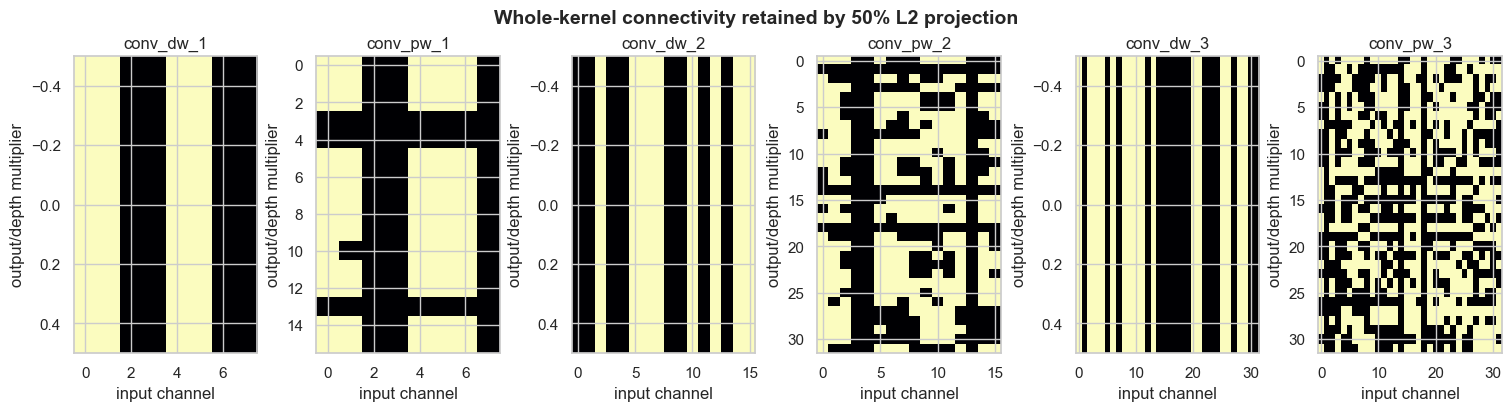

In [124]:
example_layers = [layer for layer in convolution_layers(baseline_model) if layer.name != first_conv_name][:6]
fig, axes = plt.subplots(1, len(example_layers), figsize=(15, 4), constrained_layout=True)
for ax, layer in zip(np.atleast_1d(axes), example_layers):
    _, _, mapping = project_connectivity_tensor(layer, layer.kernel.numpy(), 0.50)
    matrix = mapping.pivot(index="axis_1", columns="axis_0", values="kept").astype(float)
    ax.imshow(matrix, cmap="magma", vmin=0, vmax=1, aspect="auto")
    ax.set(title=layer.name, xlabel="input channel", ylabel="output/depth multiplier")
fig.suptitle("Whole-kernel connectivity retained by 50% L2 projection", fontsize=14, weight="bold")
fig.savefig(FIGURE_DIR / "connectivity_projection_examples.png", dpi=180, bbox_inches="tight"); plt.show()


# Part IV · Extended joint ADMM from scratch


A branch may enable either or both constraints, making pattern-only and
connectivity-only controls directly comparable with joint PatDNN.


In [125]:
@dataclass(frozen=True)
class Candidate:
    tag: str
    pattern_count: int | None
    connectivity_keep: float
    use_pattern: bool
    use_connectivity: bool

Selection is deterministic, but at several different levels.

  - Layer eligibility is rule-based:
      - Every 3×3 convolution is pattern-eligible (đạt chuẩn).
      - Every convolution except conv1 is connectivity-eligible.
      - No layers are manually cherry-picked.

  - The seven experiment configurations are predefined:
      - P6, P8, and P12 come from the PatDNN paper.
      - K75 and K50 are conservative/moderate controls.
      - K28 approximates the paper’s 3.6× connectivity pruning.
      - These ratios are registered manually, not learned automatically.

  - Pattern-library construction is model-driven but deterministic:
      1. Read the frozen Student-120 weights.
      2. Find each 3×3 kernel’s natural pattern.
      3. Count pattern frequency.
      4. Break ties using retained energy and pattern code.
      5. Select the top 6, 8, or 12.

  - Connectivity projection is deterministic:
      - Rank complete kernels by L2 norm.
      - Keep the exact requested number.
      - Break equal-score ties using their fixed tensor indices.

  - ADMM pattern assignment changes during training, but remains reproducible:
      - Fixed seed
      - Deterministic TensorFlow operations when available
      - Fixed dataset split
      - Fixed initialization
      - Fixed iteration count and learning rate

In [126]:
CANDIDATES = [
    Candidate("pattern_p06", 6, 1.0, True, False),
    Candidate("pattern_p08", 8, 1.0, True, False),
    Candidate("pattern_p12", 12, 1.0, True, False),
    Candidate("connectivity_k50", None, 0.50, False, True),
    Candidate("joint_p08_k75", 8, 0.75, True, True),
    Candidate("joint_p08_k50", 8, 0.50, True, True),
    Candidate("joint_p08_k28", 8, 1.0/3.6, True, True),
]
display(pd.DataFrame([asdict(c) for c in CANDIDATES]).style.hide(axis="index").format({"connectivity_keep":"{:.1%}"}))


tag,pattern_count,connectivity_keep,use_pattern,use_connectivity
pattern_p06,6.000000,100.0%,True,False
pattern_p08,8.000000,100.0%,True,False
pattern_p12,12.000000,100.0%,True,False
connectivity_k50,nan,50.0%,False,True
joint_p08_k75,8.000000,75.0%,True,True
joint_p08_k50,8.000000,50.0%,True,True
joint_p08_k28,8.000000,27.8%,True,True


## 13 · Initialize `Z,U,Y,V` and define the augmented loss


Pruning: 
- `Z/U` implement pattern projection and its scaled dual
- `Y/V` implement connectivity projection and its scaled dual

In [127]:
def initialize_joint_state(
        model, 
        candidate
):
    state, pattern_maps, connectivity_maps = {}, [], []

    codes = library_codes(candidate.pattern_count) if candidate.use_pattern else None
    for layer in convolution_layers(model):
        item = {}

        # PATTERN
        if candidate.use_pattern and tuple(layer.kernel_size) == (3, 3):

            z, pattern_mask, mapping = project_pattern_tensor(
                layer, 
                layer.kernel.numpy(), 
                codes
            )

            item.update(
                z=tf.Variable(z, trainable=False), 
                u=tf.Variable(tf.zeros_like(layer.kernel), trainable=False),
                pattern_mask=pattern_mask
            )

            pattern_maps.append(mapping)

        # CONNECTIVITY
        if candidate.use_connectivity:
            y, connectivity_mask, mapping = project_connectivity_tensor(
                layer, 
                layer.kernel.numpy(), 
                candidate.connectivity_keep, 
                layer.name == first_conv_name
            )

            item.update(
                y=tf.Variable(y, trainable=False), 
                v=tf.Variable(tf.zeros_like(layer.kernel), trainable=False),
                connectivity_mask=connectivity_mask
            )

            connectivity_maps.append(mapping)

        if item: state[layer.name] = item

    pattern_map = pd.concat(pattern_maps, ignore_index=True) if pattern_maps else pd.DataFrame()
    connectivity_map = pd.concat(connectivity_maps, ignore_index=True) if connectivity_maps else pd.DataFrame()

    return state, pattern_map, connectivity_map


In [128]:
def joint_admm_penalty(
        model, 
        state, 
        rho_pattern, 
        rho_connectivity
):
    pattern_terms, connectivity_terms = [], []

    for layer_name, item in state.items():
        kernel = model.get_layer(layer_name).kernel
        if "z" in item: 
            pattern_terms.append(
                0.5 * rho_pattern * tf.reduce_sum(tf.square(kernel - item["z"] + item["u"]))
            )
        if "y" in item: 
            connectivity_terms.append(
                0.5 * rho_connectivity * tf.reduce_sum(tf.square(kernel - item["y"] + item["v"]))
            )

    pattern = tf.add_n(pattern_terms) if pattern_terms else tf.constant(0.0, tf.float32)
    connectivity = tf.add_n(connectivity_terms) if connectivity_terms else tf.constant(0.0, tf.float32)
    
    return pattern, connectivity

In [129]:
def freeze_batchnorm(model):
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization): 
            layer.trainable = False

## 14 · Calibrate both penalty scales from gradient norms

Absolute loss values are not comparable across terms with different tensor counts. We choose
registered `rho` values by matching each penalty's gradient norm to a small fraction of the task
gradient on one deterministic training batch. Validation accuracy does not choose `rho`.


In [130]:
def global_norm_non_none(values):
    return float(tf.linalg.global_norm([v for v in values if v is not None]).numpy())

In [131]:
probe_model = tf.keras.models.load_model(FLOAT_MODEL_PATH, compile=False)
freeze_batchnorm(probe_model)

In [132]:
probe_candidate = Candidate(
    "rho_probe", 8, 0.50, True, True
)

In [133]:
probe_state, _, _ = initialize_joint_state(
    probe_model, 
    probe_candidate
)

In [134]:
probe_images, probe_labels = next(iter(make_training_dataset(splits["train"].iloc[:BATCH_SIZE], seed=SEED)))

In [135]:
loss_object = tf.keras.losses.BinaryCrossentropy(
    label_smoothing=LABEL_SMOOTHING
)

In [136]:
variables = probe_model.trainable_variables

In [137]:
with tf.GradientTape(persistent=True) as tape:
    probability = probe_model(probe_images, training=True)
    task_loss = loss_object(tf.reshape(probe_labels, (-1,1)), probability)
    unit_pattern, unit_connectivity = joint_admm_penalty(probe_model, probe_state, 1.0, 1.0)
task_grad = global_norm_non_none(tape.gradient(task_loss, variables))
pattern_grad = global_norm_non_none(tape.gradient(unit_pattern, variables))
connectivity_grad = global_norm_non_none(tape.gradient(unit_connectivity, variables))
del tape

In [138]:
def choose_rho(
        candidates, 
        unit_norm, 
        task_norm, 
        target
):
    table = pd.DataFrame({"rho": candidates})
    table["penalty_gradient_norm"] = table.rho * unit_norm
    table["penalty_to_task_ratio"] = table.penalty_gradient_norm / max(task_norm, 1e-12)
    table["distance"] = np.abs(np.log10(np.maximum(table.penalty_to_task_ratio, 1e-12)) - math.log10(target))
    chosen = float(table.sort_values(["distance", "rho"]).iloc[0].rho)
    table["selected"] = np.isclose(table.rho, chosen)
    return chosen, table

In [139]:
RHO_PATTERN, rho_pattern_table = choose_rho(RHO_PATTERN_CANDIDATES, pattern_grad, task_grad, TARGET_PENALTY_TO_TASK_GRADIENT_RATIO)
RHO_CONNECTIVITY, rho_connectivity_table = choose_rho(RHO_CONNECTIVITY_CANDIDATES, connectivity_grad, task_grad, TARGET_PENALTY_TO_TASK_GRADIENT_RATIO)

rho_pattern_table.assign(term="pattern").to_csv(REPORT_DIR / "rho_pattern_calibration.csv", index=False)
rho_connectivity_table.assign(term="connectivity").to_csv(REPORT_DIR / "rho_connectivity_calibration.csv", index=False)
display(pd.concat([rho_pattern_table.assign(term="pattern"), rho_connectivity_table.assign(term="connectivity")]).style.hide(axis="index").format({"rho":"{:.0e}", "penalty_to_task_ratio":"{:.3f}"}))
print({"rho_pattern": RHO_PATTERN, "rho_connectivity": RHO_CONNECTIVITY})
del probe_model, probe_state; tf.keras.backend.clear_session()

rho,penalty_gradient_norm,penalty_to_task_ratio,distance,selected,term
1e-06,0.000072,0.000,3.846457,False,pattern
3e-06,0.000215,0.000,3.369335,False,pattern
1e-05,0.000718,0.000,2.846457,False,pattern
3e-05,0.002154,0.000,2.369335,False,pattern
1e-04,0.007181,0.001,1.846457,False,pattern
3e-04,0.021544,0.002,1.369335,False,pattern
1e-03,0.071813,0.007,0.846457,False,pattern
3e-03,0.215438,0.021,0.369335,False,pattern
1e-02,0.718127,0.071,0.153543,True,pattern
1e-06,0.000107,0.000,3.671493,False,connectivity


{'rho_pattern': 0.01, 'rho_connectivity': 0.003}


## 15 · Implement the weight-update epoch


In [140]:
def run_weight_update_epoch(
        model, 
        state, 
        optimizer, 
        dataset, 
        progress_prefix="ADMM"
):
    meters = {
        name: tf.keras.metrics.Mean()
        for name in ("task", "pattern_penalty", "connectivity_penalty", "total")
    }

    objective = tf.keras.losses.BinaryCrossentropy(label_smoothing=LABEL_SMOOTHING)
    cardinality = int(tf.data.experimental.cardinality(dataset).numpy())
    report_every = max(1, cardinality // 10) if cardinality > 0 else 50
    epoch_started = time.perf_counter()

    for batch_index, (images, labels) in enumerate(dataset, start=1):
        labels = tf.reshape(labels, (-1, 1))

        with tf.GradientTape() as tape:
            probabilities = model(images, training=True)
            task = objective(labels, probabilities) + (
                tf.add_n(model.losses) if model.losses else 0.0
            )
            p_penalty, c_penalty = joint_admm_penalty(
                model, 
                state, 
                RHO_PATTERN, 
                RHO_CONNECTIVITY
            )
            total = task + p_penalty + c_penalty

        gradients = tape.gradient(
            total, 
            model.trainable_variables
        )

        optimizer.apply_gradients([
            (gradient, variable)
            for gradient, variable in zip(gradients, model.trainable_variables)
            if gradient is not None
        ])

        for key, value in zip(meters, (task, p_penalty, c_penalty, total)):
            meters[key].update_state(value)

        should_report = (
            batch_index == 1
            or batch_index % report_every == 0
            or (cardinality > 0 and batch_index == cardinality)
        )

        if should_report:
            elapsed = time.perf_counter() - epoch_started
            rate = batch_index / max(elapsed, 1e-9)
            remaining = (cardinality - batch_index) / max(rate, 1e-9) if cardinality > 0 else float("nan")
            total_text = str(cardinality) if cardinality > 0 else "?"
            eta_text = f"{remaining / 60:.1f} min" if np.isfinite(remaining) else "unknown"
            print(
                f"[{progress_prefix}] batch {batch_index}/{total_text} | "
                f"task={float(meters['task'].result()):.4f} | "
                f"pattern={float(meters['pattern_penalty'].result()):.4f} | "
                f"connectivity={float(meters['connectivity_penalty'].result()):.4f} | "
                f"total={float(meters['total'].result()):.4f} | ETA {eta_text}",
                flush=True,
            )

    return {key: float(value.result()) for key, value in meters.items()}

## 16 · Implement both projections and both dual updates


In [141]:
def update_joint_projections(
        model, 
        state, 
        candidate, 
        previous_pattern_map
):

    pattern_maps, connectivity_maps = [], []

    p_primal = p_dual = p_count = p_changes = p_kernels = 0.0
    c_primal = c_dual = c_count = 0.0

    previous = {(r.layer, r.kernel_id): int(r.pattern_code) for r in previous_pattern_map.itertuples()} if len(previous_pattern_map) else {}
    codes = library_codes(candidate.pattern_count) if candidate.use_pattern else None

    for layer_name, item in state.items():
        layer = model.get_layer(layer_name)
        weights = np.asarray(layer.kernel.numpy())

        if "z" in item:
            old_z = np.asarray(item["z"].numpy())
            value = weights + np.asarray(item["u"].numpy())
            # project
            new_z, mask, mapping = project_pattern_tensor(layer, value, codes)
            item["z"].assign(new_z)
            item["u"].assign_add(layer.kernel - item["z"])
            item["pattern_mask"] = mask

            p_primal += np.sum(np.square(weights - new_z))
            p_dual += np.sum(np.square(new_z - old_z))
            p_count += new_z.size
            for row in mapping.itertuples():
                p_changes += int(previous.get((row.layer, row.kernel_id), row.pattern_code) != row.pattern_code)
                p_kernels += 1
            pattern_maps.append(mapping)

        if "y" in item:
            old_y = np.asarray(item["y"].numpy())
            value = weights + np.asarray(item["v"].numpy())
            # project
            new_y, mask, mapping = project_connectivity_tensor(layer, value, candidate.connectivity_keep, layer.name == first_conv_name)
            item["y"].assign(new_y)
            item["v"].assign_add(layer.kernel - item["y"]); item["connectivity_mask"] = mask
            
            c_primal += np.sum(np.square(weights - new_y))
            c_dual += np.sum(np.square(new_y - old_y))
            c_count += new_y.size
            connectivity_maps.append(mapping)

    pattern_map = pd.concat(pattern_maps, ignore_index=True) if pattern_maps else pd.DataFrame()
    connectivity_map = pd.concat(connectivity_maps, ignore_index=True) if connectivity_maps else pd.DataFrame()
    residuals = {
        "pattern_primal_rms": math.sqrt(p_primal / p_count) if p_count else 0.0,
        "pattern_dual_rms": RHO_PATTERN * math.sqrt(p_dual / p_count) if p_count else 0.0,
        "pattern_reassignment_rate": p_changes / p_kernels if p_kernels else 0.0,
        "connectivity_primal_rms": math.sqrt(c_primal / c_count) if c_count else 0.0,
        "connectivity_dual_rms": RHO_CONNECTIVITY * math.sqrt(c_dual / c_count) if c_count else 0.0,
    }
    return pattern_map, connectivity_map, residuals


## 17 · Build the final intersection mask and prove no regrowth

For joint PatDNN, the mapped topology is:

```math
M_k=M_{pattern,k}\odot M_{connectivity,k}.
```

The mask callback executes after every optimizer batch. The explicit audit counts any masked
entry whose value becomes non-zero.


In [142]:
def final_masks(model, state):
    masks = {}
    for layer_name, item in state.items():
        mask = np.ones(model.get_layer(layer_name).kernel.shape, np.float32)
        if "pattern_mask" in item: 
            mask *= item["pattern_mask"]
        if "connectivity_mask" in item: 
            mask *= item["connectivity_mask"]
        masks[layer_name] = mask
    return masks

In [143]:
def apply_masks(model, masks):
    for name, mask in masks.items():
        layer = model.get_layer(name)
        layer.kernel.assign(layer.kernel * tf.convert_to_tensor(mask, layer.kernel.dtype))

In [144]:
def count_regrowth(model, masks):
    return int(sum(np.count_nonzero(np.asarray(model.get_layer(name).kernel.numpy())[mask == 0]) for name, mask in masks.items()))

In [145]:
class EnforceMasks(tf.keras.callbacks.Callback):
    def __init__(self, masks): 
        super().__init__()
        self.masks = masks
    def on_train_batch_end(self, batch, logs=None): 
        apply_masks(self.model, self.masks)
    def on_epoch_end(self, epoch, logs=None): 
        apply_masks(self.model, self.masks)
    def on_train_end(self, logs=None): 
        apply_masks(self.model, self.masks)

In [146]:
def masked_recovery(model, masks, seed):
    freeze_batchnorm(model)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(RECOVERY_LEARNING_RATE),
        loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=LABEL_SMOOTHING),
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"), 
            tf.keras.metrics.Recall(name="recall"), 
            tf.keras.metrics.AUC(curve="PR", name="pr_auc")
        ]
    )
    early = tf.keras.callbacks.EarlyStopping(monitor="val_pr_auc", mode="max", patience=RECOVERY_PATIENCE, restore_best_weights=True)
    history = model.fit(make_training_dataset(splits["train"], seed), validation_data=val_ds,
                        epochs=RECOVERY_MAX_EPOCHS, callbacks=[EnforceMasks(masks), early], verbose=2)
    apply_masks(model, masks)
    assert count_regrowth(model, masks) == 0
    return pd.DataFrame(history.history)

## 18 · Execute one registered ADMM candidate with resumable artifacts


In [147]:
def flatten_metrics(prefix, metrics):
    return {f"{prefix}_{k}": v for k,v in metrics.items() if k != "confusion_matrix"}

In [148]:
def run_candidate(candidate):
    model_path = MODEL_DIR / f"{candidate.tag}_recovered.keras"
    summary_path = REPORT_DIR / f"{candidate.tag}_summary.json"
    history_path = REPORT_DIR / f"{candidate.tag}_admm_history.csv"
    pattern_map_path = REPORT_DIR / f"{candidate.tag}_pattern_map.csv"
    connectivity_map_path = REPORT_DIR / f"{candidate.tag}_connectivity_map.csv"
    recovery_path = REPORT_DIR / f"{candidate.tag}_recovery.csv"
    mask_path = STATE_DIR / f"{candidate.tag}_masks.npz"
    paths = (model_path, summary_path, history_path, recovery_path, mask_path)

    if REUSE_CHECKPOINTS and all(p.exists() for p in paths):
        return json.loads(summary_path.read_text())["row"], pd.read_csv(history_path), pd.read_csv(recovery_path)
    
    assert RUN_TRAINING, f"Missing {candidate.tag}; set PATDNN_RUN_TRAINING=1"

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)

    model = tf.keras.models.load_model(
        FLOAT_MODEL_PATH, 
        compile=False
    )
    freeze_batchnorm(model)
    
    state, pattern_map, connectivity_map = initialize_joint_state(model, candidate)
    optimizer = tf.keras.optimizers.Adam(ADMM_LEARNING_RATE)
    
    history_rows = []
    started = time.perf_counter()
    for iteration in range(1, ADMM_ITERATIONS + 1):
        print(f"[{candidate.tag}] ADMM iteration {iteration}/{ADMM_ITERATIONS} started", flush=True)
        epoch_stats = {}
        for local_epoch in range(ADMM_EPOCHS_PER_ITERATION):

            epoch_stats = run_weight_update_epoch(
                model, 
                state, 
                optimizer,
                make_training_dataset(
                    splits["train"],
                    SEED + 1000 * iteration + local_epoch,
                ),
                progress_prefix=(
                    f"{candidate.tag} ADMM {iteration}/{ADMM_ITERATIONS} "
                    f"epoch {local_epoch + 1}/{ADMM_EPOCHS_PER_ITERATION}"
                ),
            )

        pattern_map, connectivity_map, residuals = update_joint_projections(
            model, 
            state, 
            candidate, 
            pattern_map
        )
        _, probabilities = collect_predictions(model, val_ds)
        metrics = evaluate_validation(
            val_labels, 
            probabilities
        )
        row = {
            "tag": candidate.tag, 
            "iteration": iteration, 
            **epoch_stats, 
            **residuals,
            "val_f1": metrics["f1"], 
            "val_recall": metrics["recall"], 
            "val_pr_auc": metrics["pr_auc"]
        }
        history_rows.append(row)
        pd.DataFrame(history_rows).to_csv(history_path, index=False)
        print(f"[{candidate.tag}] validation after ADMM {iteration}: {row}", flush=True)

    # masks
    masks = final_masks(model, state)
    apply_masks(model, masks)

    # Map
    _, mapped_probabilities = collect_predictions(
        model, 
        val_ds
    )
    mapped = evaluate_validation(
        val_labels, 
        mapped_probabilities
    )

    # Recovery
    recovery = masked_recovery(
        model, 
        masks, 
        SEED
    )
    _, recovered_probabilities = collect_predictions(model, val_ds)
    recovered = evaluate_validation(val_labels, recovered_probabilities)

    elapsed = time.perf_counter() - started

    model.save(model_path)
    np.savez_compressed(mask_path, **masks)
    history = pd.DataFrame(history_rows)
    history.to_csv(history_path, index=False)
    recovery.insert(0, "epoch", np.arange(1, len(recovery)+1))
    recovery.to_csv(recovery_path, index=False)
    if len(pattern_map): 
        pattern_map.to_csv(pattern_map_path, index=False)
    if len(connectivity_map): 
        connectivity_map.to_csv(connectivity_map_path, index=False)
    total = sum(mask.size for mask in masks.values())
    zeros = sum(np.count_nonzero(mask == 0) for mask in masks.values())
    result = {
        "tag": candidate.tag, 
        **asdict(candidate), 
        "rho_pattern": RHO_PATTERN, 
        "rho_connectivity": RHO_CONNECTIVITY,
        "admm_iterations": ADMM_ITERATIONS, 
        "recovery_epochs": len(recovery), 
        "training_seconds": elapsed,
        "masked_weight_sparsity": zeros / total, 
        "zero_regrowth": count_regrowth(model, masks),
        "model_path": str(model_path.relative_to(ROOT)), 
        "mask_path": str(mask_path.relative_to(ROOT)),
        **flatten_metrics("mapped", mapped), 
        **flatten_metrics("recovered", recovered)
    }
    summary_path.write_text(json.dumps({"candidate": asdict(candidate), "row": result, "mapped": mapped, "recovered": recovered}, indent=2)+"\n")
    del model, state
    tf.keras.backend.clear_session()
    
    return result, history, recovery


## 19 · Run or reuse the complete training matrix


In [149]:
required_training_symbols = ("val_ds", "val_labels", "baseline_val_metrics", "evaluate_validation")
missing_training_symbols = [name for name in required_training_symbols if name not in globals()]
assert not missing_training_symbols, (
    f"Section 19 prerequisites are missing: {missing_training_symbols}. "
    "Restart the kernel and run Sections 1-18 in order."
)

candidate_rows, admm_histories, recovery_histories = [], [], []

if RUN_TRAINING or all((REPORT_DIR / f"{c.tag}_summary.json").exists() for c in CANDIDATES):
    for candidate_index, candidate in enumerate(CANDIDATES, start=1):
        print("\n" + "=" * 88, flush=True)
        print(
            f"Candidate {candidate_index}/{len(CANDIDATES)}: {candidate.tag} | "
            f"patterns={candidate.pattern_count} | connectivity_keep={candidate.connectivity_keep:.1%}",
            flush=True,
        )
        candidate_started = time.perf_counter()
        row, history, recovery = run_candidate(candidate)
        print(
            f"Completed {candidate.tag} in {(time.perf_counter() - candidate_started) / 60:.1f} min | "
            f"recovered F1={row['recovered_f1']:.3f} | recall={row['recovered_recall']:.3f}",
            flush=True,
        )
        candidate_rows.append(row)
        admm_histories.append(history)
        recovery_histories.append(recovery.assign(tag=candidate.tag))
        
    candidate_results = pd.DataFrame(candidate_rows)
    all_admm_history = pd.concat(admm_histories, ignore_index=True)
    all_recovery_history = pd.concat(recovery_histories, ignore_index=True)
    candidate_results["f1_drop"] = baseline_val_metrics["f1"] - candidate_results.recovered_f1
    candidate_results["passes_quality"] = (candidate_results.recovered_recall >= MINIMUM_RECALL) & (candidate_results.f1_drop <= MAXIMUM_F1_DROP)
    candidate_results.to_csv(REPORT_DIR / "float_candidate_comparison.csv", index=False)
    all_admm_history.to_csv(REPORT_DIR / "all_admm_history.csv", index=False)
    all_recovery_history.to_csv(REPORT_DIR / "all_recovery_history.csv", index=False)
    display(candidate_results.style.hide(axis="index").format({"connectivity_keep":"{:.1%}", "masked_weight_sparsity":"{:.1%}", "recovered_f1":"{:.3f}", "recovered_recall":"{:.3f}", "f1_drop":"{:+.3f}"}))
else:
    candidate_results = pd.DataFrame()
    print("Training intentionally skipped. Set PATDNN_RUN_TRAINING=1, restart the kernel, and Run All.")



Candidate 1/7: pattern_p06 | patterns=6 | connectivity_keep=100.0%
Completed pattern_p06 in 0.0 min | recovered F1=0.669 | recall=0.949

Candidate 2/7: pattern_p08 | patterns=8 | connectivity_keep=100.0%
Completed pattern_p08 in 0.0 min | recovered F1=0.671 | recall=0.951

Candidate 3/7: pattern_p12 | patterns=12 | connectivity_keep=100.0%
Completed pattern_p12 in 0.0 min | recovered F1=0.666 | recall=0.986

Candidate 4/7: connectivity_k50 | patterns=None | connectivity_keep=50.0%
Completed connectivity_k50 in 0.0 min | recovered F1=0.662 | recall=1.000

Candidate 5/7: joint_p08_k75 | patterns=8 | connectivity_keep=75.0%
Completed joint_p08_k75 in 0.0 min | recovered F1=0.662 | recall=1.000

Candidate 6/7: joint_p08_k50 | patterns=8 | connectivity_keep=50.0%
Completed joint_p08_k50 in 0.0 min | recovered F1=0.662 | recall=1.000

Candidate 7/7: joint_p08_k28 | patterns=8 | connectivity_keep=27.8%
Completed joint_p08_k28 in 0.0 min | recovered F1=0.662 | recall=1.000


tag,pattern_count,connectivity_keep,use_pattern,use_connectivity,rho_pattern,rho_connectivity,admm_iterations,recovery_epochs,training_seconds,masked_weight_sparsity,zero_regrowth,model_path,mask_path,mapped_samples,mapped_threshold,mapped_accuracy,mapped_precision,mapped_recall,mapped_f1,mapped_roc_auc,mapped_pr_auc,mapped_specificity,mapped_positive_prevalence,mapped_predicted_positive_rate,mapped_ece_10,recovered_samples,recovered_threshold,recovered_accuracy,recovered_precision,recovered_recall,recovered_f1,recovered_roc_auc,recovered_pr_auc,recovered_specificity,recovered_positive_prevalence,recovered_predicted_positive_rate,recovered_ece_10,f1_drop,passes_quality
pattern_p06,6.000000,100.0%,True,False,0.010000,0.003000,6,6,1382.768909,55.6%,0,artifacts/pruning/patdnn_student_120/models/pattern_p06_recovered.keras,artifacts/pruning/patdnn_student_120/state/pattern_p06_masks.npz,2000,0.285000,0.496500,0.495491,1.000000,0.662647,0.476683,0.475619,0.003956,0.494500,0.998000,0.143013,2000,0.400000,0.535000,0.516218,0.949,0.669,0.613528,0.585023,0.129575,0.494500,0.909500,0.036626,+0.114,False
pattern_p08,8.000000,100.0%,True,False,0.010000,0.003000,6,6,1762.191218,55.6%,0,artifacts/pruning/patdnn_student_120/models/pattern_p08_recovered.keras,artifacts/pruning/patdnn_student_120/state/pattern_p08_masks.npz,2000,0.185000,0.495000,0.494747,1.000000,0.661981,0.484405,0.487789,0.000989,0.494500,0.999500,0.255630,2000,0.380000,0.538000,0.517887,0.951,0.671,0.617614,0.599006,0.133531,0.494500,0.908500,0.050163,+0.112,False
pattern_p12,12.000000,100.0%,True,False,0.010000,0.003000,6,4,1454.405064,55.6%,0,artifacts/pruning/patdnn_student_120/models/pattern_p12_recovered.keras,artifacts/pruning/patdnn_student_120/state/pattern_p12_masks.npz,2000,0.320000,0.501500,0.497970,0.991911,0.663062,0.526258,0.509463,0.021761,0.494500,0.985000,0.117871,2000,0.455000,0.512000,0.503356,0.986,0.666,0.573738,0.567393,0.048467,0.494500,0.968500,0.026947,+0.116,False
connectivity_k50,nan,50.0%,False,True,0.010000,0.003000,6,6,1643.994774,49.9%,0,artifacts/pruning/patdnn_student_120/models/connectivity_k50_recovered.keras,artifacts/pruning/patdnn_student_120/state/connectivity_k50_masks.npz,2000,0.010000,0.494500,0.494500,1.000000,0.661760,0.495924,0.485604,0.000000,0.494500,1.000000,0.434296,2000,0.010000,0.494500,0.494500,1.000,0.662,0.525774,0.518122,0.000000,0.494500,1.000000,0.012957,+0.121,False
joint_p08_k75,8.000000,75.0%,True,True,0.010000,0.003000,6,6,1651.166530,27.3%,0,artifacts/pruning/patdnn_student_120/models/joint_p08_k75_recovered.keras,artifacts/pruning/patdnn_student_120/state/joint_p08_k75_masks.npz,2000,0.010000,0.494500,0.494500,1.000000,0.661760,0.463529,0.470933,0.000000,0.494500,1.000000,0.054527,2000,0.010000,0.494500,0.494500,1.000,0.662,0.609452,0.597042,0.000000,0.494500,1.000000,0.008038,+0.121,False
joint_p08_k50,8.000000,50.0%,True,True,0.010000,0.003000,6,3,1020.522933,51.5%,0,artifacts/pruning/patdnn_student_120/models/joint_p08_k50_recovered.keras,artifacts/pruning/patdnn_student_120/state/joint_p08_k50_masks.npz,2000,0.010000,0.494500,0.494500,1.000000,0.661760,0.473483,0.483468,0.000000,0.494500,1.000000,0.366853,2000,0.010000,0.494500,0.494500,1.000,0.662,0.530757,0.529919,0.000000,0.494500,1.000000,0.007122,+0.121,False
joint_p08_k28,8.000000,27.8%,True,True,0.010000,0.003000,6,3,1015.253852,73.0%,0,artifacts/pruning/patdnn_student_120/models/joint_p08_k28_recovered.keras,artifacts/pruning/patdnn_student_120/state/joint_p08_k28_masks.npz,2000,0.010000,0.494500,0.494500,1.000000,0.661760,0.526322,0.511071,0.000000,0.494500,1.000000,0.324591,2000,0.010000,0.494500,0.494500,1.000,0.662,0.518597,0.512191,0.000000,0.494500,1.000000,0.012701,+0.121,False


## 20 · Diagnose convergence instead of trusting the final epoch


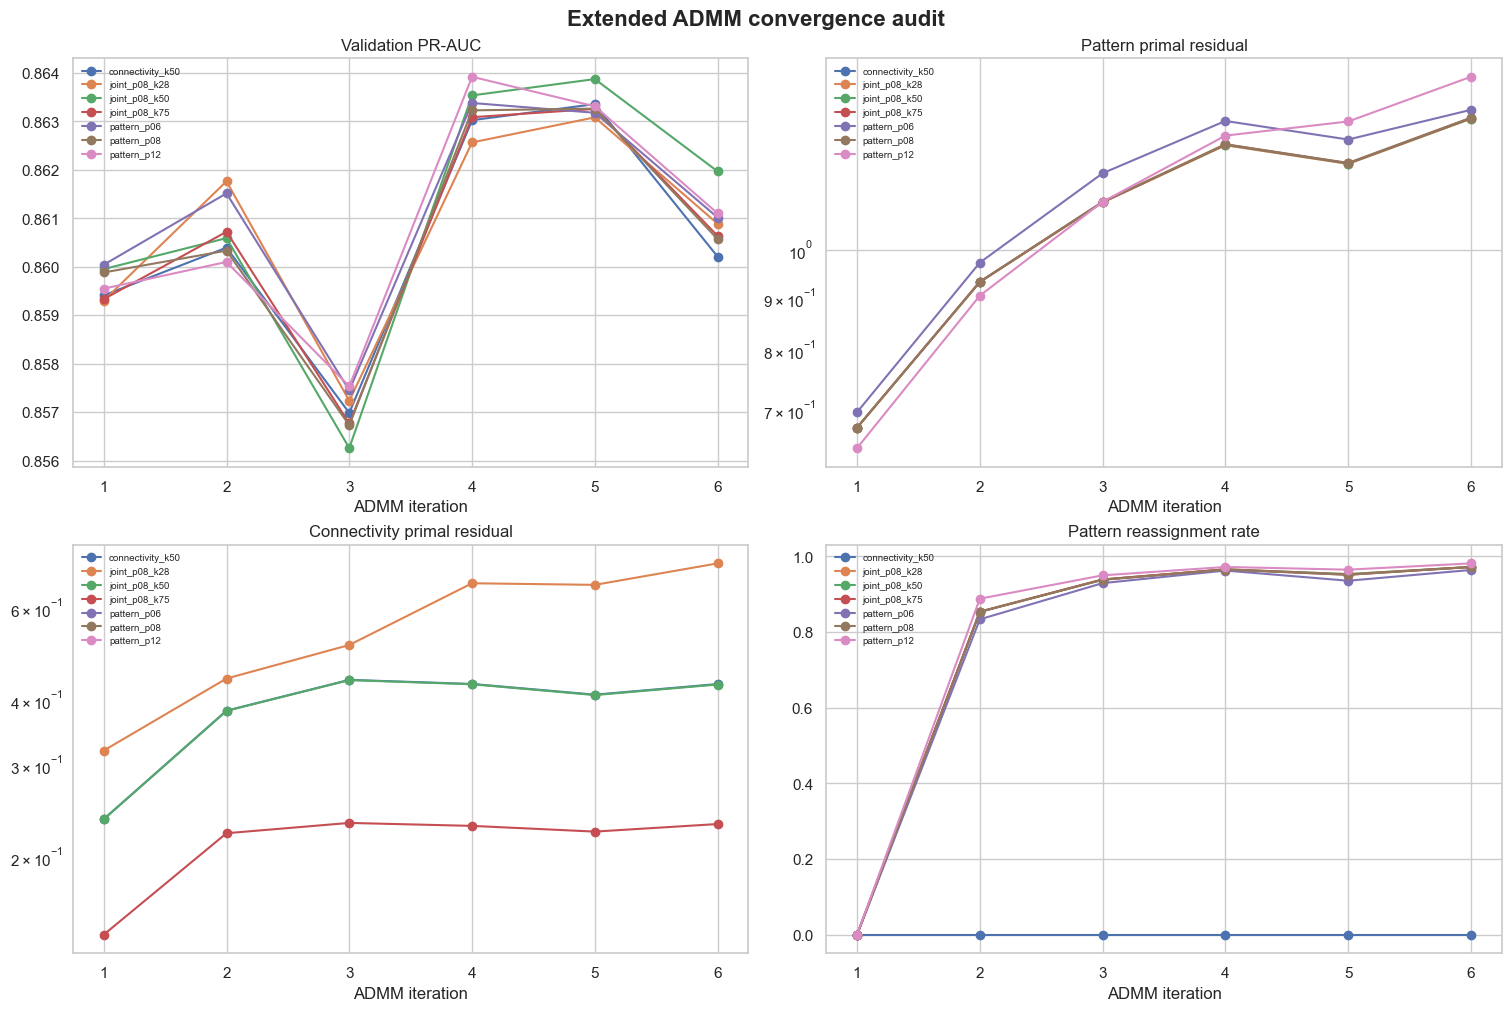

In [150]:
if len(candidate_results):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)
    for tag, frame in all_admm_history.groupby("tag"):
        axes[0,0].plot(frame.iteration, frame.val_pr_auc, marker="o", label=tag)
        axes[0,1].plot(frame.iteration, frame.pattern_primal_rms, marker="o", label=tag)
        axes[1,0].plot(frame.iteration, frame.connectivity_primal_rms, marker="o", label=tag)
        axes[1,1].plot(frame.iteration, frame.pattern_reassignment_rate, marker="o", label=tag)
    axes[0,0].set(title="Validation PR-AUC", xlabel="ADMM iteration")
    axes[0,1].set(title="Pattern primal residual", xlabel="ADMM iteration", yscale="log")
    axes[1,0].set(title="Connectivity primal residual", xlabel="ADMM iteration", yscale="log")
    axes[1,1].set(title="Pattern reassignment rate", xlabel="ADMM iteration")
    for ax in axes.flat: ax.legend(frameon=False, fontsize=7)
    fig.suptitle("Extended ADMM convergence audit", fontsize=16, weight="bold")
    fig.savefig(FIGURE_DIR / "joint_admm_convergence.png", dpi=180, bbox_inches="tight"); plt.show()


# Part V · Full-INT8 control and candidate selection

The dense masked TFLite export verifies quality and quantization compatibility. It is **not** the
PatDNN runtime. Sparse runtime evidence begins only after LR/FKW/codegen.


In [151]:
def representative_dataset(frame, samples=REPRESENTATIVE_SAMPLES):
    subset = frame.sample(n=min(samples, len(frame)), random_state=SEED)
    for images, _ in make_eval_dataset(subset, batch_size=1): yield [images]

In [152]:
def collect_tflite_predictions(
        path, 
        dataset
):
    interpreter = tf.lite.Interpreter(model_path=str(path))
    interpreter.allocate_tensors()

    input_detail = interpreter.get_input_details()[0]
    output_detail = interpreter.get_output_details()[0]

    in_scale, in_zero = input_detail["quantization"]
    out_scale, out_zero = output_detail["quantization"]
    labels, probabilities = [], []
    for images, targets in dataset:
        labels.extend(np.asarray(targets).reshape(-1).astype(int))
        for image in np.asarray(images):
            q = np.clip(np.round(image / in_scale + in_zero), -128, 127).astype(np.int8)[None]
            interpreter.set_tensor(input_detail["index"], q)
            interpreter.invoke()
            raw = interpreter.get_tensor(output_detail["index"])[0,0]
            probabilities.append((float(raw)-out_zero)*out_scale)
            
    return np.asarray(labels), np.asarray(probabilities)

In [153]:
export_rows = []

if len(candidate_results):
    specs = [("baseline", FLOAT_MODEL_PATH)] + [(row.tag, ROOT / row.model_path) for row in candidate_results.itertuples()]
    for tag, keras_path in specs:
        tflite_path = MODEL_DIR / f"{tag}_dense_control_int8.tflite"
        
        if not (REUSE_CHECKPOINTS and tflite_path.exists()):
            model = tf.keras.models.load_model(
                keras_path, 
                compile=False
            )
            convert_full_integer(
                model, 
                representative_dataset(splits["train"]), 
                tflite_path
            )
            del model; tf.keras.backend.clear_session()

        info = inspect_tflite(tflite_path)
        assert info["input"]["shape"] == [1,120,120,3] and info["input"]["dtype"] == "int8" and info["output"]["dtype"] == "int8"

        labels, probabilities = collect_tflite_predictions(tflite_path, val_ds)
        metrics = evaluate_validation(labels, probabilities)
        
        export_rows.append(
            {
                "tag": tag, 
                "path": str(tflite_path.relative_to(ROOT)), 
                "bytes": tflite_path.stat().st_size,
                "gzip_bytes": len(gzip.compress(tflite_path.read_bytes(), compresslevel=9)), 
                "sha256": sha256_file(tflite_path),
                **{k: metrics[k] for k in ("threshold","accuracy","precision","recall","specificity","f1","roc_auc","pr_auc","ece_10")}
            }
        )

/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/tensorf

In [154]:
int8_results = pd.DataFrame(export_rows)

if len(int8_results):
    baseline_int8 = int8_results[int8_results.tag == "baseline"].iloc[0]
    selectable = int8_results[int8_results.tag.str.startswith("joint_")].copy()
    assert len(selectable), "No joint PatDNN candidate was exported"

    selectable["f1_drop"] = baseline_int8.f1 - selectable.f1
    selectable["passes_quality"] = (selectable.recall >= MINIMUM_RECALL) & (selectable.f1_drop <= MAXIMUM_F1_DROP)
    
    pool = selectable[selectable.passes_quality] if selectable.passes_quality.any() else selectable
    selected = pool.sort_values(["f1", "pr_auc"], ascending=False).iloc[0]
    
    SELECTED_TAG = str(selected.tag)
    SELECTED_INT8_PATH = ROOT / selected.path
    int8_results.to_csv(REPORT_DIR / "int8_validation_comparison.csv", index=False)
    display(int8_results.style.hide(axis="index").format({k:"{:.3f}" for k in ("threshold","accuracy","recall","f1","pr_auc","ece_10")}))
    print({"selected": SELECTED_TAG, "selection": "validation only"})

tag,path,bytes,gzip_bytes,sha256,threshold,accuracy,precision,recall,specificity,f1,roc_auc,pr_auc,ece_10
baseline,artifacts/pruning/patdnn_student_120/models/baseline_dense_control_int8.tflite,304528,220305,a8a19cb6839ec6a26274c228482e725c3068fca94cbaf585d9bdb0774af6cbc3,0.270,0.764,0.733514,0.821,0.708210,0.775,0.852301,0.855,0.092
pattern_p06,artifacts/pruning/patdnn_student_120/models/pattern_p06_dense_control_int8.tflite,304528,217111,f084e34ca3a4e0e03587fd8290832a7f75e0f0c89b6fb475663f31cc5edce026,0.405,0.538,0.518026,0.944,0.140455,0.669,0.611540,0.582,0.040
pattern_p08,artifacts/pruning/patdnn_student_120/models/pattern_p08_dense_control_int8.tflite,304528,217158,854120a8d2c1fd8847f3891126aa3d0b606c50ee07dcc2e7e20ed382d8d15ad5,0.330,0.519,0.507006,0.988,0.060336,0.670,0.618490,0.601,0.068
pattern_p12,artifacts/pruning/patdnn_student_120/models/pattern_p12_dense_control_int8.tflite,304528,217342,60586379d5ad02b4fdb6e9fa2e41a9b2fc3ba6e67936998251cf5a86d59a1e11,0.445,0.501,0.497728,0.997,0.015826,0.664,0.568996,0.551,0.027
connectivity_k50,artifacts/pruning/patdnn_student_120/models/connectivity_k50_dense_control_int8.tflite,304528,174590,c039fb4980e79cca539598aa16234e6d450a1a888038f916973ecf9e0b094f26,0.010,0.494,0.494500,1.000,0.000000,0.662,0.515311,0.504,0.014
joint_p08_k75,artifacts/pruning/patdnn_student_120/models/joint_p08_k75_dense_control_int8.tflite,304528,204089,3bec5d36d2ef149db3ac9918c9c39b01b095be589b5cdb1f95a3eeadbc7d31c2,0.485,0.520,0.508030,0.960,0.090999,0.664,0.595063,0.556,0.005
joint_p08_k50,artifacts/pruning/patdnn_student_120/models/joint_p08_k50_dense_control_int8.tflite,304528,171098,3eac4ea28f2b697f7f0990d42690ad3945bdc42215b48d6dd4186c180e9ca66e,0.010,0.494,0.494500,1.000,0.000000,0.662,0.500000,0.494,0.006
joint_p08_k28,artifacts/pruning/patdnn_student_120/models/joint_p08_k28_dense_control_int8.tflite,304528,124061,2b8835a6e592bc8c6cf91dee8bfe74d9d4085441f50dbae47c3cc6aadff1fb46,0.010,0.494,0.494500,1.000,0.000000,0.662,0.500000,0.494,0.006


{'selected': 'joint_p08_k75', 'selection': 'validation only'}


## 21 · Open the held-out test once


In [155]:
if len(int8_results):
    baseline_path = ROOT / int8_results[int8_results.tag == "baseline"].iloc[0].path
    test_labels, baseline_test_prob = collect_tflite_predictions(baseline_path, test_ds)
    _, selected_test_prob = collect_tflite_predictions(SELECTED_INT8_PATH, test_ds)
    baseline_test = classification_metrics(test_labels, baseline_test_prob, float(baseline_int8.threshold))
    selected_test = classification_metrics(test_labels, selected_test_prob, float(selected.threshold))
    test_table = pd.DataFrame([{"model":"Student-120 dense INT8", **baseline_test},
                               {"model":SELECTED_TAG, **selected_test}])
    test_table.to_csv(REPORT_DIR / "held_out_test_comparison.csv", index=False)
    display(test_table.drop(columns="confusion_matrix").style.hide(axis="index").format({k:"{:.3f}" for k in ("threshold","accuracy","precision","recall","specificity","f1","roc_auc","pr_auc")}))


/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
2026-10-07 15:08:09.436165: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


model,samples,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,specificity,positive_prevalence,predicted_positive_rate
Student-120 dense INT8,2000,0.270,0.768,0.745,0.802,0.773,0.853,0.857,0.736,0.490500,0.528000
joint_p08_k75,2000,0.485,0.525,0.509,0.957,0.664,0.593,0.549,0.110,0.490500,0.923000


## 22 · Confusion matrices and quantization damage


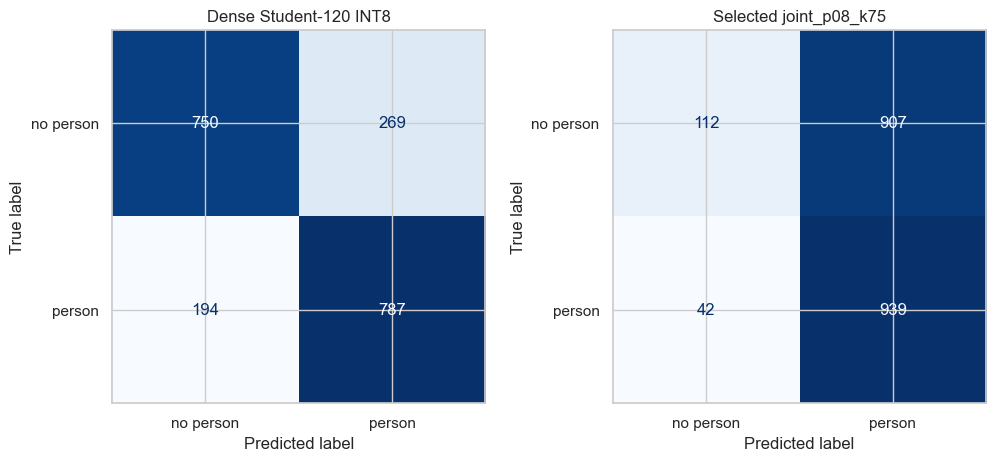

In [156]:
if len(int8_results):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)
    for ax, title, metrics in zip(axes, ("Dense Student-120 INT8", f"Selected {SELECTED_TAG}"), (baseline_test, selected_test)):
        ConfusionMatrixDisplay(np.asarray(metrics["confusion_matrix"]), display_labels=["no person","person"]).plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(title)
    fig.savefig(FIGURE_DIR / "held_out_confusion_matrices.png", dpi=180, bbox_inches="tight"); plt.show()


# Part VI · Extract INT8 convolution tensors and quantization metadata

TFLite stores standard convolution filters as `OHWI` and depthwise filters as
`[1,H,W,Cout]`. The code below walks operator inputs rather than guessing tensor names, then maps
them back to Keras convolution order. This is the quantization boundary for FKW generation.


In [157]:
def extract_tflite_convolutions(tflite_path, keras_model):
    interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
    interpreter.allocate_tensors()
    details = {d["index"]: d for d in interpreter.get_tensor_details()}
    ops = [op for op in interpreter._get_ops_details() if op["op_name"] in {"CONV_2D", "DEPTHWISE_CONV_2D"}]
    layers = convolution_layers(keras_model)
    assert len(ops) == len(layers), (len(ops), len(layers))
    records = []
    for layer, op in zip(layers, ops):
        weight_index = int(op["inputs"][1])
        bias_index = int(op["inputs"][2])
        raw = interpreter.get_tensor(weight_index)
        bias = interpreter.get_tensor(bias_index)
        if isinstance(layer, tf.keras.layers.DepthwiseConv2D):
            h,w = raw.shape[1:3]; logical = raw.reshape(h, w, layer.kernel.shape[2], layer.kernel.shape[3])
        else:
            logical = np.transpose(raw, (1,2,3,0))
        records.append({"layer": layer.name, "kind": layer.__class__.__name__, "op": op["op_name"], "weights": logical, "bias": bias,
                        "weight_detail": details[weight_index], "input_detail": details[int(op["inputs"][0])],
                        "output_detail": details[int(op["outputs"][0])]})
    return records


if len(int8_results):
    selected_float_path = ROOT / candidate_results.set_index("tag").loc[SELECTED_TAG, "model_path"]
    selected_model = tf.keras.models.load_model(selected_float_path, compile=False)
    quantized_conv_records = extract_tflite_convolutions(SELECTED_INT8_PATH, selected_model)
    print({r["layer"]: {"op":r["op"], "shape":r["weights"].shape, "dtype":str(r["weights"].dtype)} for r in quantized_conv_records})


{'conv1': {'op': 'CONV_2D', 'shape': (3, 3, 3, 8), 'dtype': 'int8'}, 'conv_dw_1': {'op': 'DEPTHWISE_CONV_2D', 'shape': (3, 3, 8, 1), 'dtype': 'int8'}, 'conv_pw_1': {'op': 'CONV_2D', 'shape': (1, 1, 8, 16), 'dtype': 'int8'}, 'conv_dw_2': {'op': 'DEPTHWISE_CONV_2D', 'shape': (3, 3, 16, 1), 'dtype': 'int8'}, 'conv_pw_2': {'op': 'CONV_2D', 'shape': (1, 1, 16, 32), 'dtype': 'int8'}, 'conv_dw_3': {'op': 'DEPTHWISE_CONV_2D', 'shape': (3, 3, 32, 1), 'dtype': 'int8'}, 'conv_pw_3': {'op': 'CONV_2D', 'shape': (1, 1, 32, 32), 'dtype': 'int8'}, 'conv_dw_4': {'op': 'DEPTHWISE_CONV_2D', 'shape': (3, 3, 32, 1), 'dtype': 'int8'}, 'conv_pw_4': {'op': 'CONV_2D', 'shape': (1, 1, 32, 64), 'dtype': 'int8'}, 'conv_dw_5': {'op': 'DEPTHWISE_CONV_2D', 'shape': (3, 3, 64, 1), 'dtype': 'int8'}, 'conv_pw_5': {'op': 'CONV_2D', 'shape': (1, 1, 64, 64), 'dtype': 'int8'}, 'conv_dw_6': {'op': 'DEPTHWISE_CONV_2D', 'shape': (3, 3, 64, 1), 'dtype': 'int8'}, 'conv_pw_6': {'op': 'CONV_2D', 'shape': (1, 1, 64, 128), 'dtype':

/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


# Part VII · Layerwise Representation (§5.1)

The LR is the contract between trained topology and generated code. It records shapes, patterns,
connectivity, quantization, reorder, FKW offsets, loop schedule, and memory placement. A generated
kernel is invalid if its LR cannot be validated.


## 23 · Audit graph-level optimization before layerwise lowering

PatDNN adopts TVM-like graph passes before its paper-specific layerwise optimizations. TFLite
conversion already performs constant folding and common operator fusion. This audit records the
actual exported operator graph and identifies convolution boundaries that will be replaced by the
generated executor. It does not claim that generic graph fusion is a novel PatDNN contribution.

In [158]:
def tflite_operator_inventory(path):
    interpreter = tf.lite.Interpreter(model_path=str(path))
    interpreter.allocate_tensors()
    rows = []
    for index, op in enumerate(interpreter._get_ops_details()):
        rows.append(
            {
                "op_index":index, 
                "op":op["op_name"], 
                "inputs":len(op["inputs"]),
                "outputs":len(op["outputs"]), 
                "patdnn_replaceable":op["op_name"] in {"CONV_2D","DEPTHWISE_CONV_2D"}
            }
        )
    return pd.DataFrame(rows)

if len(int8_results):
    graph_inventory = tflite_operator_inventory(SELECTED_INT8_PATH)
    graph_inventory.to_csv(REPORT_DIR / "tflite_graph_inventory.csv", index=False)
    display(graph_inventory.groupby(["op","patdnn_replaceable"]).size().rename("count").reset_index().style.hide(axis="index"))

op,patdnn_replaceable,count
ADD,False,1
CONV_2D,True,14
DELEGATE,False,1
DEPTHWISE_CONV_2D,True,13
FULLY_CONNECTED,False,1
LOGISTIC,False,1
MEAN,False,1
MUL,False,1
PAD,False,2


## 24 · Build and validate the Layerwise Representation

This machine-readable contract binds pruning topology, quantization, convolution geometry, memory placement, and the schedule consumed by code generation.


In [159]:
def quantization_dict(detail):
    q = detail["quantization_parameters"]
    return {
        "scales": np.asarray(q["scales"]).astype(float).tolist(),
        "zero_points": np.asarray(q["zero_points"]).astype(int).tolist(),
        "quantized_dimension": int(q["quantized_dimension"]), 
        "dtype": str(detail["dtype"])
    }


def build_layerwise_representation(model, records, selected_tag):
    layers = []
    for layer, record in zip(convolution_layers(model), records):
        mask_file = np.load(STATE_DIR / f"{selected_tag}_masks.npz")
        mask = mask_file[layer.name] if layer.name in mask_file.files else np.ones(layer.kernel.shape, np.float32)
        layers.append({
            "name": layer.name, 
            "kind": layer.__class__.__name__, 
            "kernel_shape_hwio": list(map(int, layer.kernel.shape)),
            "input_shape": [int(x) if x is not None else None for x in layer.input.shape],
            "output_shape": [int(x) if x is not None else None for x in layer.output.shape],
            "strides": list(map(int, layer.strides)), 
            "dilation": list(map(int, layer.dilation_rate)), 
            "padding": layer.padding,
            "depth_multiplier": int(layer.depth_multiplier) if isinstance(layer, tf.keras.layers.DepthwiseConv2D) else None,
            "pattern_eligible": tuple(layer.kernel_size) == (3,3), 
            "nonzero_weights": int(np.count_nonzero(mask)),
            "surviving_connections": int(sum(np.any(kernel) for _, kernel in iter_kernels(layer, mask))),
            "input_quantization": quantization_dict(record["input_detail"]),
            "weight_quantization": quantization_dict(record["weight_detail"]),
            "output_quantization": quantization_dict(record["output_detail"]),
            "tuning": {
                "loop_order":"oh_ow_oc_pattern_ic", 
                "tile_oh":1, 
                "tile_ow":4, 
                "unroll_oc":1,
                "unroll_ic":1, 
                "weights":"flash", 
                "hot_accumulators":"internal_sram"
            },
        })

    return {
        "schema":"esp-patdnn-lr-v1", 
        "model":selected_tag, 
        "input":[1,120,120,3], 
        "layers":layers
    }


def validate_lr(lr):
    assert lr["schema"] == "esp-patdnn-lr-v1" and lr["input"] == [1,120,120,3]
    names = [x["name"] for x in lr["layers"]]; assert len(names) == len(set(names))
    for layer in lr["layers"]:
        assert len(layer["kernel_shape_hwio"]) == 4 and layer["surviving_connections"] >= 1
        assert layer["weight_quantization"]["scales"], layer["name"]
    return True


if len(int8_results):
    lr = build_layerwise_representation(selected_model, quantized_conv_records, SELECTED_TAG)
    assert validate_lr(lr)
    lr_path = LR_DIR / f"{SELECTED_TAG}_layerwise_representation.json"
    lr_path.write_text(json.dumps(lr, indent=2)+"\n")
    display(pd.DataFrame(lr["layers"])[["name","kind","kernel_shape_hwio","pattern_eligible","nonzero_weights","surviving_connections"]].style.hide(axis="index"))


name,kind,kernel_shape_hwio,pattern_eligible,nonzero_weights,surviving_connections
conv1,Conv2D,"[3, 3, 3, 8]",True,96,24
conv_dw_1,DepthwiseConv2D,"[3, 3, 8, 1]",True,24,6
conv_pw_1,Conv2D,"[1, 1, 8, 16]",False,96,96
conv_dw_2,DepthwiseConv2D,"[3, 3, 16, 1]",True,48,12
conv_pw_2,Conv2D,"[1, 1, 16, 32]",False,384,384
conv_dw_3,DepthwiseConv2D,"[3, 3, 32, 1]",True,96,24
conv_pw_3,Conv2D,"[1, 1, 32, 32]",False,768,768
conv_dw_4,DepthwiseConv2D,"[3, 3, 32, 1]",True,96,24
conv_pw_4,Conv2D,"[1, 1, 32, 64]",False,1536,1536
conv_dw_5,DepthwiseConv2D,"[3, 3, 64, 1]",True,192,48


# Part VIII · Filter/kernel reorder (§5.2)

Kernel reorder groups identical pattern IDs within each filter. Filter reorder first groups equal
workload and then greedily maximizes adjacency similarity. The inverse output permutation is
always saved; reorder must never change semantic channel order.


In [160]:
def canonical_connectivity_weights(
        weights, 
        kind
):
    """Return [H, W, Cin, Cout] connectivity weights for reorder/FKW analysis.

    A standard Conv2D tensor already has this layout.  A depthwise tensor has
    [H, W, Cin, depth_multiplier], so each input channel must be expanded onto
    the corresponding diagonal output-channel connection.  This is a logical
    analysis representation; it does not change the deployed TFLite tensor.
    """
    weights = np.asarray(weights)
    assert weights.ndim == 4, f"Expected rank-4 convolution weights, got {weights.shape}"

    if kind != "DepthwiseConv2D":
        return weights

    height, width, input_channels, depth_multiplier = weights.shape
    assert height > 0 and width > 0 and input_channels > 0 and depth_multiplier > 0

    output_channels = input_channels * depth_multiplier
    expanded = np.zeros(
        (
            height, 
            width, 
            input_channels, 
            output_channels
        ),
        dtype=weights.dtype,
    )

    for input_channel in range(input_channels):
        for multiplier_index in range(depth_multiplier):
            output_channel = input_channel * depth_multiplier + multiplier_index
            expanded[
                :, :, input_channel, output_channel
            ] = weights[
                :, :, input_channel, multiplier_index
            ]

    # Expansion introduces only structural zeros; every original coefficient
    # must appear exactly once in the canonical connectivity tensor.
    assert np.array_equal(
        expanded[
            :, :,
            np.repeat(np.arange(input_channels), depth_multiplier),
            np.arange(output_channels),
        ].reshape(height, width, input_channels, depth_multiplier),
        weights,
    )
    
    return expanded

In [161]:
def connection_pattern(kernel, codes):
    if kernel.shape == (1,1): 
        return 0
    nonzero = (np.asarray(kernel) != 0).astype(np.float32)
    pattern_code = mask_to_code(nonzero)
    if pattern_code in codes: 
        return codes.index(pattern_code)
    squared = np.square(np.asarray(kernel, dtype=np.int32))  # INT8 square must be promoted
    return int(np.argmax([np.sum(squared * code_to_mask(c)) for c in codes]))

In [162]:
def filter_signature(weights, codes):
    signatures = []
    for output_index in range(weights.shape[3]):
        entries = []
        for input_index in range(weights.shape[2]):
            kernel = weights[:,:,input_index,output_index]
            if np.any(kernel): 
                entries.append((connection_pattern(kernel, codes), input_index))
        entries.sort()
        signatures.append(entries)
    return signatures

In [163]:
def signature_similarity(a, b):
    return len(set(a).intersection(b))

In [164]:
def filter_kernel_reorder(
        weights, 
        codes
):
    signatures = filter_signature(
        weights, 
        codes
    )
    remaining = set(range(len(signatures))); order = []
    
    for workload in sorted(set(map(len, signatures))):
        group = {i for i in remaining if len(signatures[i]) == workload}
        
        if not group: 
            continue
        
        current = min(group)
        order.append(current)
        group.remove(current)
        remaining.remove(current)
        
        while group:
            nxt = sorted(
                group, 
                key=lambda j: (
                    -signature_similarity(
                        signatures[current], 
                        signatures[j]
                    ), 
                    j
                )
            )[0]

            order.append(nxt)
            group.remove(nxt)
            remaining.remove(nxt)
            current = nxt
            
    assert sorted(order) == list(range(len(signatures)))
    inverse = np.argsort(order)
    reordered = [sorted(signatures[o], key=lambda pair:(pair[0],pair[1])) for o in order]
    return np.asarray(order, np.int32), np.asarray(inverse, np.int32), reordered

## 25 · Audit reorder regularity


In [165]:
def pattern_switches(signatures):
    return sum(
        sum(a[0] != b[0] for a,b in zip(items[:-1], items[1:])) for items in signatures
    )

In [167]:
def adjacent_similarity(signatures):
    return sum(signature_similarity(a,b) for a,b in zip(signatures[:-1], signatures[1:]))

In [168]:
reorder_audit = []
if len(int8_results):
    p8 = library_codes(8)
    for record in quantized_conv_records:
        
        weights = canonical_connectivity_weights(
            record["weights"], 
            record["kind"]
        )
        codes = p8 if weights.shape[:2] == (3,3) else [1]
        before = filter_signature(weights, codes); order, inverse, after = filter_kernel_reorder(weights, codes)

        assert np.array_equal(order[inverse], np.arange(len(order)))
        reorder_audit.append(
            {
                "layer":record["layer"], 
                "filters":len(order), 
                "pattern_switches_before":pattern_switches(before),
                "pattern_switches_after":pattern_switches(after),
                "adjacent_similarity_before":adjacent_similarity(before),
                "adjacent_similarity_after":adjacent_similarity(after)
            }
        )
    reorder_audit = pd.DataFrame(reorder_audit)
    reorder_audit.to_csv(REPORT_DIR / "fkr_audit.csv", index=False)
    display(reorder_audit.style.hide(axis="index"))

layer,filters,pattern_switches_before,pattern_switches_after,adjacent_similarity_before,adjacent_similarity_after
conv1,8,6,6,1,3
conv_dw_1,8,0,0,0,0
conv_pw_1,16,0,0,38,49
conv_dw_2,16,0,0,0,0
conv_pw_2,32,0,0,278,316
conv_dw_3,32,0,0,0,0
conv_pw_3,32,0,0,604,639
conv_dw_4,32,0,0,0,0
conv_pw_4,64,0,0,1162,1239
conv_dw_5,64,0,0,0,0


## 26 · Quantify filter-level LRE groups after FKR

For adjacent reordered filters, a shared `(pattern, input channel)` pair means the same input
vector can feed multiple output accumulators. The table measures those opportunities separately
from kernel-level sliding-window reuse.

In [169]:
filter_lre_rows = []
if len(int8_results):
    p8 = library_codes(8)
    for record in quantized_conv_records:
        weights = canonical_connectivity_weights(
            record["weights"], 
            record["kind"]
        )
        codes = p8 if weights.shape[:2] == (3,3) else [1]
        
        _, _, signatures = filter_kernel_reorder(
            weights, 
            codes
        )
        shared = [
            signature_similarity(a,b) for a,b in zip(signatures[:-1], signatures[1:])
        ]
        filter_lre_rows.append(
            {
                "layer":record["layer"], 
                "adjacent_filter_pairs":len(shared),
                "shared_pattern_input_pairs":int(sum(shared)),
                "mean_shared_per_pair":float(np.mean(shared)) if shared else 0.0,
                "max_shared_per_pair":int(max(shared, default=0))
            }
        )
    filter_lre_audit = pd.DataFrame(filter_lre_rows)
    filter_lre_audit.to_csv(REPORT_DIR / "filter_lre_opportunity.csv", index=False)
    display(filter_lre_audit.style.hide(axis="index").format({"mean_shared_per_pair":"{:.2f}"}))

layer,adjacent_filter_pairs,shared_pattern_input_pairs,mean_shared_per_pair,max_shared_per_pair
conv1,7,3,0.43,1
conv_dw_1,7,0,0.00,0
conv_pw_1,15,49,3.27,5
conv_dw_2,15,0,0.00,0
conv_pw_2,31,316,10.19,13
conv_dw_3,31,0,0.00,0
conv_pw_3,31,639,20.61,27
conv_dw_4,31,0,0.00,0
conv_pw_4,63,1239,19.67,29
conv_dw_5,63,0,0.00,0


# Part IX · Five-array FKW storage (§5.3)

Pattern identity is encoded by each filter's `stride` boundaries, so no per-kernel pattern array
is needed. `offset` and `reorder` are filter-level; `index` and `stride` are kernel-level metadata;
`weight` contains only retained entries.


In [170]:
def smallest_uint(maximum):
    if maximum <= np.iinfo(np.uint8).max: 
        return np.uint8
    if maximum <= np.iinfo(np.uint16).max: 
        return np.uint16
    return np.uint32

In [ ]:
def encode_fkw(
        weights, 
        codes
):
    
    weights = np.asarray(weights)
    order, inverse, grouped = filter_kernel_reorder(weights, codes)
    offsets = [0]
    indices = []
    strides = []
    packed_weights = []
    masks = [code_to_mask(code).astype(bool) for code in codes] if weights.shape[:2] == (3,3) else [np.ones((1,1), bool)]
    
    for original_filter, entries in zip(order, grouped):
        filter_start = len(indices)
        boundaries = [filter_start]

        for pattern_id, pattern_mask in enumerate(masks):
            for pid, input_channel in entries:
                if pid != pattern_id: continue
                kernel = weights[:,:,input_channel,original_filter]
                indices.append(input_channel)
                packed_weights.extend(kernel[pattern_mask].tolist())

            boundaries.append(len(indices))

        strides.extend(boundaries)
        offsets.append(len(indices))
    
    offset_dtype = smallest_uint(max(offsets))
    index_dtype = smallest_uint(max(indices, default=0))
    stride_dtype = smallest_uint(max(strides, default=0))
    reorder_dtype = smallest_uint(max(order, default=0))
    arrays = {
        "offset":np.asarray(offsets, offset_dtype), 
        "reorder":order.astype(reorder_dtype),
        "index":np.asarray(indices,index_dtype), 
        "stride":np.asarray(strides,stride_dtype),
        "weight":np.asarray(packed_weights, weights.dtype)
    }
    meta = {
        "shape":list(map(int,weights.shape)), 
        "patterns":[int(c) for c in codes], 
        "stride_width":len(codes)+1,
        "dtypes":{k:str(v.dtype) for k,v in arrays.items()}, 
        "inverse_reorder":inverse.tolist()
    }
    
    return arrays, meta


In [ ]:
def decode_fkw(
        arrays, 
        meta
):
    shape = tuple(meta["shape"])
    dense = np.zeros(shape, dtype=arrays["weight"].dtype)
    masks = [code_to_mask(c).astype(bool) for c in meta["patterns"]] if shape[:2] == (3,3) else [np.ones((1,1),bool)]
    values_per_kernel = int(masks[0].sum())
    weight_cursor = 0
    width = meta["stride_width"]
    
    for reordered_filter, original_filter in enumerate(arrays["reorder"].astype(int)):
        boundaries = arrays["stride"][reordered_filter*width : (reordered_filter+1)*width].astype(int)
        
        for pattern_id, mask in enumerate(masks):
            for connection in range(boundaries[pattern_id], boundaries[pattern_id+1]):
                input_channel = int(arrays["index"][connection])
                dense[:,:,input_channel,original_filter][mask] = arrays["weight"][weight_cursor:weight_cursor+values_per_kernel]
                weight_cursor += values_per_kernel
    assert weight_cursor == len(arrays["weight"])
    return dense

## 27 · Encode every selected INT8 convolution and demand exact round-trip


In [173]:
fkw_rows = []
fkw_packages = {}

In [174]:
if len(int8_results):
    p8 = library_codes(8)

    for record in quantized_conv_records:
        original_weights = record["weights"]
        weights = canonical_connectivity_weights(
            original_weights, 
            record["kind"]
        )
        codes = p8 if weights.shape[:2] == (3,3) else [1]

        arrays, meta = encode_fkw(weights, codes)

        decoded = decode_fkw(arrays, meta)
        
        exact = np.array_equal(decoded, weights)
        
        assert exact, record["layer"]
        layer_dir = FKW_DIR / record["layer"]
        layer_dir.mkdir(exist_ok=True)
        np.savez_compressed(layer_dir / "arrays.npz", **arrays)
        (layer_dir / "manifest.json").write_text(json.dumps(meta, indent=2)+"\n")
        dense_bytes = original_weights.nbytes
        payload = arrays["weight"].nbytes
        metadata = sum(v.nbytes for k,v in arrays.items() if k != "weight")
        fkw_rows.append(
            {
                "layer":record["layer"], 
                "dense_bytes":dense_bytes, 
                "weight_payload_bytes":payload,
                "metadata_bytes":metadata, 
                "total_fkw_bytes":payload+metadata,
                "compression":dense_bytes/(payload+metadata), 
                "roundtrip_exact":exact
            }
        )
        fkw_packages[record["layer"]] = (arrays, meta)
    fkw_audit = pd.DataFrame(fkw_rows); fkw_audit.to_csv(REPORT_DIR / "fkw_storage_audit.csv", index=False)
    display(fkw_audit.style.hide(axis="index").format({"compression":"{:.2f}×"}))


layer,dense_bytes,weight_payload_bytes,metadata_bytes,total_fkw_bytes,compression,roundtrip_exact
conv1,216,72,107,179,1.21×,True
conv_dw_1,72,24,95,119,0.61×,True
conv_pw_1,128,57,122,179,0.72×,True
conv_dw_2,144,48,189,237,0.61×,True
conv_pw_2,512,349,575,924,0.55×,True
conv_dw_3,288,96,377,473,0.61×,True
conv_pw_3,1024,761,987,1748,0.59×,True
conv_dw_4,288,96,377,473,0.61×,True
conv_pw_4,2048,1535,1985,3520,0.58×,True
conv_dw_5,576,192,753,945,0.61×,True


## 28 · Visualize payload versus metadata—the cost usually hidden by sparsity percentages


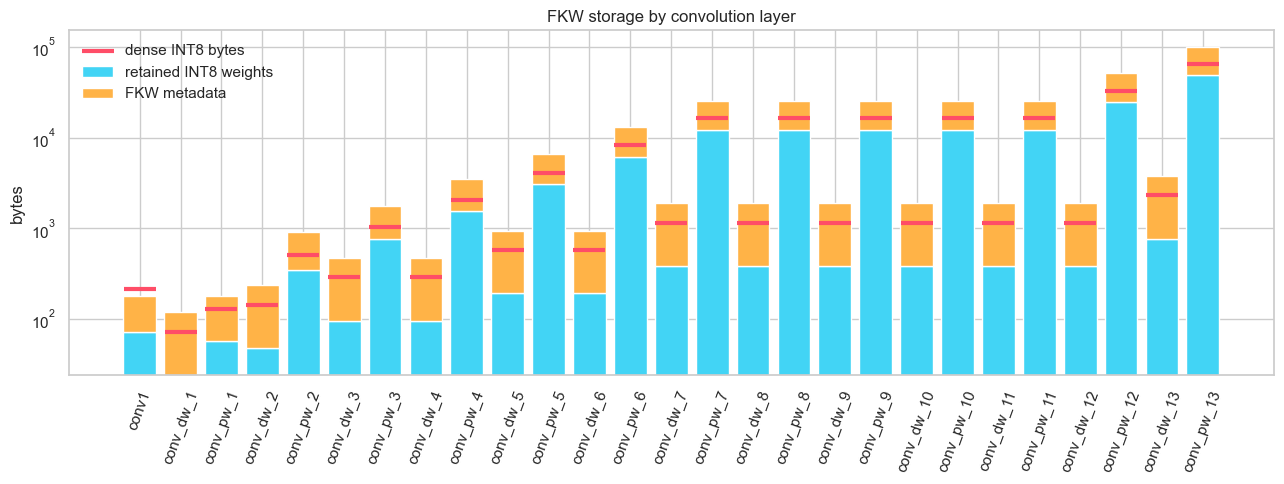

In [175]:
if len(int8_results):
    x = np.arange(len(fkw_audit)); fig, ax = plt.subplots(figsize=(13,5))
    ax.bar(x, fkw_audit.weight_payload_bytes, label="retained INT8 weights", color="#42d4f5")
    ax.bar(x, fkw_audit.metadata_bytes, bottom=fkw_audit.weight_payload_bytes, label="FKW metadata", color="#ffb347")
    ax.scatter(x, fkw_audit.dense_bytes, marker="_", s=500, linewidths=3, color="#ff4d67", label="dense INT8 bytes")
    ax.set(title="FKW storage by convolution layer", ylabel="bytes", xticks=x, xticklabels=fkw_audit.layer, yscale="log")
    ax.tick_params(axis="x", rotation=70); ax.legend(frameon=False)
    fig.tight_layout(); fig.savefig(FIGURE_DIR / "fkw_payload_metadata.png", dpi=180, bbox_inches="tight"); plt.show()


# Part X · Load redundancy elimination (§5.4)

Kernel-level LRE uses static spatial offsets and reuses overlap between adjacent windows.
Filter-level LRE finds `(input channel, pattern)` groups shared by adjacent reordered filters so
one input vector feeds several accumulators. The following analysis counts opportunities; only
compiled device timings establish benefit.


## 29 · Measure kernel-level LRE opportunities


In [176]:
def pattern_coordinates(pattern_code):
    return [tuple(map(int, rc)) for rc in np.argwhere(code_to_mask(pattern_code) != 0)]

In [177]:
def kernel_sliding_loads(
        pattern_code, 
        output_width
):
    coords = pattern_coordinates(pattern_code)
    naive = len(coords) * output_width
    unique = len({(r, c+x) for x in range(output_width) for r,c in coords})
    return naive, unique

In [178]:
def filter_reuse_groups(
        grouped_signatures
):
    groups = Counter()
    for entries in grouped_signatures:
        for pair in entries: groups[pair] += 1
    return groups

In [179]:
lre_rows = []
for size in PATTERN_LIBRARY_SIZES:
    for code_value in library_codes(size):
        naive, unique = kernel_sliding_loads(code_value, output_width=8)
        lre_rows.append(
            {
                "library_size":size, 
                "pattern_code":code_value, 
                "naive_loads":naive,
                "unique_window_loads":unique, 
                "modeled_reduction":1-unique/naive
            }
        )
lre_audit = pd.DataFrame(lre_rows)
lre_audit.to_csv(REPORT_DIR / "kernel_lre_opportunity.csv", index=False)
display(lre_audit.groupby("library_size").modeled_reduction.agg(["mean","min","max"]).style.format("{:.1%}"))

,mean,min,max
library_size,,,
6,32.3%,18.8%,43.8%
8,29.7%,18.8%,43.8%
12,32.3%,18.8%,43.8%


# Part XI · Branch-free C++ generation

The generator emits pattern-specific spatial offsets as constants. Pattern dispatch occurs
outside the connection loop through the FKW `stride` ranges. It produces portable scalar C++ as
a correctness reference; ESP32-S3 SIMD specialization uses the same LR/FKW ABI and is benchmarked
as a separate backend.


## 30 · Generate compileable pattern-specialized accumulator headers


In [180]:
def c_array(name, array):
    ctype = {
        "int8":"int8_t",
        "uint8":"uint8_t",
        "uint16":"uint16_t",
        "uint32":"uint32_t",
        "int32":"int32_t"
    }.get(str(array.dtype), "int32_t")
    values = ", ".join(map(str, array.reshape(-1).tolist()))
    return f"static const {ctype} {name}[{array.size}] = {{{values}}};"

In [181]:
def emit_pattern_executor(layer_name, arrays, meta):
    safe = "".join(ch if ch.isalnum() else "_" for ch in layer_name)
    lines = ["#pragma once", "#include <stdint.h>", "#include <stddef.h>", ""]
    for key in ("offset","reorder","index","stride","weight"):
        lines.append(c_array(f"{safe}_{key}", arrays[key]))
    stride_width = int(meta["stride_width"])
    weight_per_kernel = 4 if tuple(meta["shape"][:2]) == (3,3) else 1
    lines += ["", f"// FKW scalar correctness kernel for {layer_name}.",
              "// input points at the top-left of one receptive field.",
              f"static inline void {safe}_accumulate_pixel(const int8_t* input, int input_width, int input_stride_c,",
              "    size_t reordered_filter, int32_t* acc) {",
              f"  const size_t oc = {safe}_reorder[reordered_filter];"]
    for pattern_id, pattern_code in enumerate(meta["patterns"]):
        coordinates = pattern_coordinates(pattern_code) if weight_per_kernel == 4 else [(0,0)]
        lines.append(f"  // Pattern {pattern_id}, code {pattern_code}: branch-free spatial accesses.")
        lines.append(f"  const size_t begin_{pattern_id} = {safe}_stride[reordered_filter * {stride_width} + {pattern_id}];")
        lines.append(f"  const size_t end_{pattern_id} = {safe}_stride[reordered_filter * {stride_width} + {pattern_id + 1}];")
        lines.append(f"  for (size_t connection = begin_{pattern_id}; connection < end_{pattern_id}; ++connection) {{")
        lines.append(f"    const int ic = {safe}_index[connection];")
        weight_base = "connection * 4" if weight_per_kernel == 4 else "connection"
        for wi,(r,c) in enumerate(coordinates):
            lines.append(f"    acc[oc] += (int32_t)input[({r} * input_width + {c}) * input_stride_c + ic] * (int32_t){safe}_weight[{weight_base} + {wi}];")
        lines.append("  }")
    lines += ["}", ""]
    return "\n".join(lines)

In [182]:
if len(int8_results):
    generated_rows = []
    for layer_name,(arrays,meta) in fkw_packages.items():
        header = emit_pattern_executor(layer_name, arrays, meta)
        path = GENERATED_DIR / f"{layer_name}_patdnn.h"; path.write_text(header)
        generated_rows.append({"layer":layer_name, "header":str(path.relative_to(ROOT)), "bytes":path.stat().st_size,
                               "sha256":sha256_file(path)})
    generated_inventory = pd.DataFrame(generated_rows); generated_inventory.to_csv(REPORT_DIR / "generated_code_inventory.csv", index=False)
    display(generated_inventory.style.hide(axis="index"))

layer,header,bytes,sha256
conv1,artifacts/pruning/patdnn_student_120/generated/conv1_patdnn.h,7524,441cfe5cb063fd7ea9b50aac509644731450b24ee807ee1ac5840734e8bfc600
conv_dw_1,artifacts/pruning/patdnn_student_120/generated/conv_dw_1_patdnn.h,7484,ffab33fe1c47bee818467d4671a7c8c9222764920cdc4aacdbcef9df266b7997
conv_pw_1,artifacts/pruning/patdnn_student_120/generated/conv_pw_1_patdnn.h,1675,65afdb8c1d2229786de8fc7dd6379d2caf607248ee58bb46066e2c201fe7303d
conv_dw_2,artifacts/pruning/patdnn_student_120/generated/conv_dw_2_patdnn.h,7916,a1c75c9544d61a2b940d2db7cf4a9800c1800ea6cb325e479dcf36db3927ac5a
conv_pw_2,artifacts/pruning/patdnn_student_120/generated/conv_pw_2_patdnn.h,4183,387d900a76f96b18e8af23a59d6ce16fa7783d48ef5ff4f363b70934876602d2
conv_dw_3,artifacts/pruning/patdnn_student_120/generated/conv_dw_3_patdnn.h,8859,32133800533805f1082d450cb43bc30cace8a4645477eb4a2f141eb0017638cb
conv_pw_3,artifacts/pruning/patdnn_student_120/generated/conv_pw_3_patdnn.h,7554,431123ccb69775f0ea889c6979d9eb672d7367cace63ab23e9e76064ebd7bf37
conv_dw_4,artifacts/pruning/patdnn_student_120/generated/conv_dw_4_patdnn.h,8839,63678493079b4028aab8b53e3c79f751c1565f506c32ab091276f777924eb383
conv_pw_4,artifacts/pruning/patdnn_student_120/generated/conv_pw_4_patdnn.h,14471,0c77d28c2164575cfb818b32a24579a9f3368e54922e0388fa0efb11eaca75b8
conv_dw_5,artifacts/pruning/patdnn_student_120/generated/conv_dw_5_patdnn.h,10744,aea7fc7db64f4c0b1ddfbe069c52d5b0a87474f09340cbd5bd9e727a730a9130


## 31 · Host-side numerical verification ladder

The FKW round-trip above is bit-exact. The next executable gates are deliberately separate:

1. dense masked INT8 tensor ↔ decoded FKW tensor;
2. no-opt Python sparse convolution ↔ dense integer accumulation;
3. FKR executor ↔ no-opt executor after inverse reorder;
4. generated scalar C++ ↔ Python FKR executor;
5. LRE and SIMD backends ↔ scalar C++;
6. end-to-end device output ↔ dense TFLite control.

Do not jump directly to latency: a fast numerically wrong kernel is a failed experiment.


In [183]:
def dense_accumulate_patch(patch, weights):
    return np.tensordot(patch.astype(np.int32), weights.astype(np.int32), axes=([0,1,2],[0,1,2]))


def fkw_accumulate_patch(patch, arrays, meta):
    decoded = decode_fkw(arrays, meta)
    return dense_accumulate_patch(patch, decoded)


parity_rows = []
if len(int8_results):
    rng = np.random.default_rng(SEED)
    for layer_name,(arrays,meta) in fkw_packages.items():
        shape = tuple(meta["shape"]); patch = rng.integers(-128,128,size=(shape[0],shape[1],shape[2]),dtype=np.int16).astype(np.int8)
        dense = decode_fkw(arrays,meta)
        expected = dense_accumulate_patch(patch,dense)
        actual = fkw_accumulate_patch(patch,arrays,meta)
        parity_rows.append({"layer":layer_name, "max_abs_accumulator_error":int(np.max(np.abs(expected-actual))), "exact":np.array_equal(expected,actual)})
    parity_audit = pd.DataFrame(parity_rows); assert parity_audit.exact.all()
    parity_audit.to_csv(REPORT_DIR / "integer_accumulator_parity.csv", index=False)
    display(parity_audit.style.hide(axis="index"))


layer,max_abs_accumulator_error,exact
conv1,0,True
conv_dw_1,0,True
conv_pw_1,0,True
conv_dw_2,0,True
conv_pw_2,0,True
conv_dw_3,0,True
conv_pw_3,0,True
conv_dw_4,0,True
conv_pw_4,0,True
conv_dw_5,0,True


# Part XII · Parameter auto-tuning (§5.5)

The paper combines a genetic explorer with a learned performance estimator. Here, chromosomes
are first filtered by an ESP32 memory model; measured device latency is the fitness. A surrogate
may rank proposals only after measured history exists. Host timing is never mixed with ESP32
timing.


In [ ]:
@dataclass(frozen=True)
class Schedule:
    tile_oh: int
    tile_ow: int
    unroll_oc: int
    unroll_ic: int
    loop_order: str
    filter_group: int
    workspace: str


SEARCH_SPACE = {
    "tile_oh": (1,2,4), 
    "tile_ow": (1,2,4,8), 
    "unroll_oc": (1,2,4), 
    "unroll_ic": (1,2,4),
    "loop_order": (
        "oh_ow_oc_pic", 
        "oc_oh_ow_pic", 
        "oh_oc_ow_pic"
    ), 
    "filter_group": (1,2,4),
    "workspace": (
        "internal_sram", 
        "psram"
    ),
}


def random_schedule(rng):
    return Schedule(**{key: rng.choice(values) for key,values in SEARCH_SPACE.items()})


def estimated_scratch_bytes(schedule, input_channels, output_channels):
    input_tile = (schedule.tile_oh + 2) * (schedule.tile_ow + 2) * input_channels
    accumulators = schedule.tile_oh * schedule.tile_ow * min(schedule.unroll_oc, output_channels) * 4
    return int(input_tile + accumulators)


def valid_schedule(schedule, layer_shape, internal_sram_budget=32*1024):
    scratch = estimated_scratch_bytes(schedule, layer_shape[2], layer_shape[3])
    return schedule.workspace == "psram" or scratch <= internal_sram_budget


def mutate(schedule, rng, probability=0.25):
    values = asdict(schedule)
    for key, domain in SEARCH_SPACE.items():
        if rng.random() < probability: values[key] = rng.choice(domain)
    return Schedule(**values)



def crossover(left, right, rng):
    a, b = asdict(left), asdict(right)
    return Schedule(**{key:(a[key] if rng.random() < 0.5 else b[key]) for key in a})


def next_measured_generation(measurements, layer_shape, population_size=24, elite_fraction=0.25, seed=SEED):
    required = {"device_median_us", *SEARCH_SPACE.keys()}
    assert required.issubset(measurements.columns), required - set(measurements.columns)
    ranked = measurements.dropna(subset=["device_median_us"]).sort_values("device_median_us")
    assert len(ranked) >= 4, "At least four measured schedules are required for genetic selection"
    elite_count = max(2, int(math.ceil(population_size * elite_fraction)))
    elites = [Schedule(**{key:row[key] for key in SEARCH_SPACE}) for _,row in ranked.head(elite_count).iterrows()]
    rng = random.Random(seed); generation = list(elites)
    while len(generation) < population_size:
        tournament = rng.sample(elites, k=min(3,len(elites)))
        left = min(tournament, key=lambda x: float(ranked[
            np.logical_and.reduce([ranked[k] == v for k,v in asdict(x).items()])
        ].device_median_us.iloc[0]))
        right = rng.choice(elites)
        child = mutate(crossover(left,right,rng),rng)
        if valid_schedule(child,layer_shape) and child not in generation: generation.append(child)
    return generation

def genetic_proposals(layer_shape, population_size=24, generations=8, seed=SEED):
    rng = random.Random(seed); population = []
    while len(population) < population_size:
        candidate = random_schedule(rng)
        if valid_schedule(candidate, layer_shape) and candidate not in population: population.append(candidate)
    # Fitness is intentionally absent until device measurements are joined. Emit a diverse queue.
    proposals = list(population)
    for _ in range(generations-1):
        parents = population[:max(2,population_size//4)]
        children = []
        while len(children) < population_size:
            child = mutate(rng.choice(parents), rng)
            if valid_schedule(child, layer_shape) and child not in children: children.append(child)
        proposals.extend(children)
        population = children
    return list(dict.fromkeys(proposals))


autotune_rows = []
if len(int8_results):
    for layer in lr["layers"]:
        for candidate_id, schedule in enumerate(genetic_proposals(layer["kernel_shape_hwio"])[:64]):
            autotune_rows.append(
                {
                    "layer":layer["name"], 
                    "candidate_id":candidate_id, 
                    **asdict(schedule),
                    "estimated_scratch_bytes":estimated_scratch_bytes(schedule, layer["kernel_shape_hwio"][2], layer["kernel_shape_hwio"][3]),
                    "device_median_us":np.nan
                }
            )
    autotune_queue = pd.DataFrame(autotune_rows)
    autotune_queue.to_csv(REPORT_DIR / "device_autotune_queue.csv", index=False)
    print({"autotune_candidates":len(autotune_queue), "fitness":"pending physical device measurements"})


{'autotune_candidates': 1728, 'fitness': 'pending physical device measurements'}


## 32 · Device timing ingestion and winner selection

The firmware capture appends `device_median_us`, `p95_us`, code bytes, scratch bytes, and board ID
to the queue. Winner selection rejects parity failures and memory violations, ranks median latency,
then confirms the winner in a fresh timing run. This cell refuses to invent a winner from an
unmeasured queue.


In [185]:
def select_measured_schedule(frame, board):
    measured = frame[(frame.board == board) & frame.device_median_us.notna() & frame.parity_pass].copy()
    assert len(measured), f"No valid physical measurements for {board}"
    winners = measured.sort_values(["layer","device_median_us"]).groupby("layer", as_index=False).first()
    return winners


timing_capture_path = REPORT_DIR / "device_autotune_measurements.csv"
if timing_capture_path.exists():
    device_tuning = pd.read_csv(timing_capture_path)
    for board in sorted(device_tuning.board.unique()):
        winners = select_measured_schedule(device_tuning, board)
        winners.to_csv(REPORT_DIR / f"{board}_autotune_winners.csv", index=False)
        display(Markdown(f"### {board}")); display(winners.style.hide(axis="index"))
else:
    print("No device tuning capture yet; no timing winner is declared.")


No device tuning capture yet; no timing winner is declared.


# Part XIII · Runtime ablation and physical deployment

The mandatory ablation mirrors the paper:

```text
dense TFLM/ESP-NN
sparse no-opt
sparse + FKR
sparse + FKR + LRE
full sparse + FKR + LRE + tuned schedule
```

Both boards use batch one and illumination disabled during profiling. Camera capture,
preprocessing, Invoke/generated-executor, postprocessing, and complete-loop latency are captured
separately.


In [186]:
DEVICE_VARIANT = f"patdnn_student120_{SELECTED_TAG}" if len(int8_results) else "patdnn_student120_pending"
device_commands = pd.DataFrame([
    {"board":"esp32_cam", "dense_control": f"scripts/profile_esp32_model.sh {SELECTED_INT8_PATH.relative_to(ROOT) if len(int8_results) else '<model>'} 120 {DEVICE_VARIANT}_dense /dev/cu.usbserial-120",
     "patdnn_runtime": f"scripts/profile_patdnn_model.sh esp32_cam {OUTPUT_DIR.relative_to(ROOT)} {DEVICE_VARIANT} /dev/cu.usbserial-120"},
    {"board":"esp32_s3", "dense_control": f"scripts/profile_esp32_s3_model.sh {SELECTED_INT8_PATH.relative_to(ROOT) if len(int8_results) else '<model>'} 120 10487648 245760 {DEVICE_VARIANT}_dense /dev/cu.usbmodem1101",
     "patdnn_runtime": f"scripts/profile_patdnn_model.sh esp32_s3 {OUTPUT_DIR.relative_to(ROOT)} {DEVICE_VARIANT} /dev/cu.usbmodem1101"},
])
display(device_commands.style.hide(axis="index"))
print("The PatDNN profiling command becomes executable after the generated runtime is integrated; it is not a dense-TFLite alias.")


board,dense_control,patdnn_runtime
esp32_cam,scripts/profile_esp32_model.sh artifacts/pruning/patdnn_student_120/models/joint_p08_k75_dense_control_int8.tflite 120 patdnn_student120_joint_p08_k75_dense /dev/cu.usbserial-120,scripts/profile_patdnn_model.sh esp32_cam artifacts/pruning/patdnn_student_120 patdnn_student120_joint_p08_k75 /dev/cu.usbserial-120
esp32_s3,scripts/profile_esp32_s3_model.sh artifacts/pruning/patdnn_student_120/models/joint_p08_k75_dense_control_int8.tflite 120 10487648 245760 patdnn_student120_joint_p08_k75_dense /dev/cu.usbmodem1101,scripts/profile_patdnn_model.sh esp32_s3 artifacts/pruning/patdnn_student_120 patdnn_student120_joint_p08_k75 /dev/cu.usbmodem1101


The PatDNN profiling command becomes executable after the generated runtime is integrated; it is not a dense-TFLite alias.


## 33 · Merge physical measurements without fabricating missing rows


In [187]:
device_result_paths = {
    "esp32_cam": ROOT / "artifacts/device_profiles" / DEVICE_VARIANT / "esp32_cam" / "device_profile_summary.json",
    "esp32_s3": ROOT / "artifacts/device_profiles" / DEVICE_VARIANT / "esp32_s3" / "device_profile_summary.json",
}
device_rows = []
for board,path in device_result_paths.items():
    if path.exists(): device_rows.append({"board":board, "path":str(path.relative_to(ROOT)), **json.loads(path.read_text())})
device_results = pd.DataFrame(device_rows)
if len(device_results): display(device_results.style.hide(axis="index"))
else: print("Physical PatDNN device evidence is pending. The report will say pending.")


Physical PatDNN device evidence is pending. The report will say pending.


## 34 · Final quality, storage, computation, and runtime dashboard


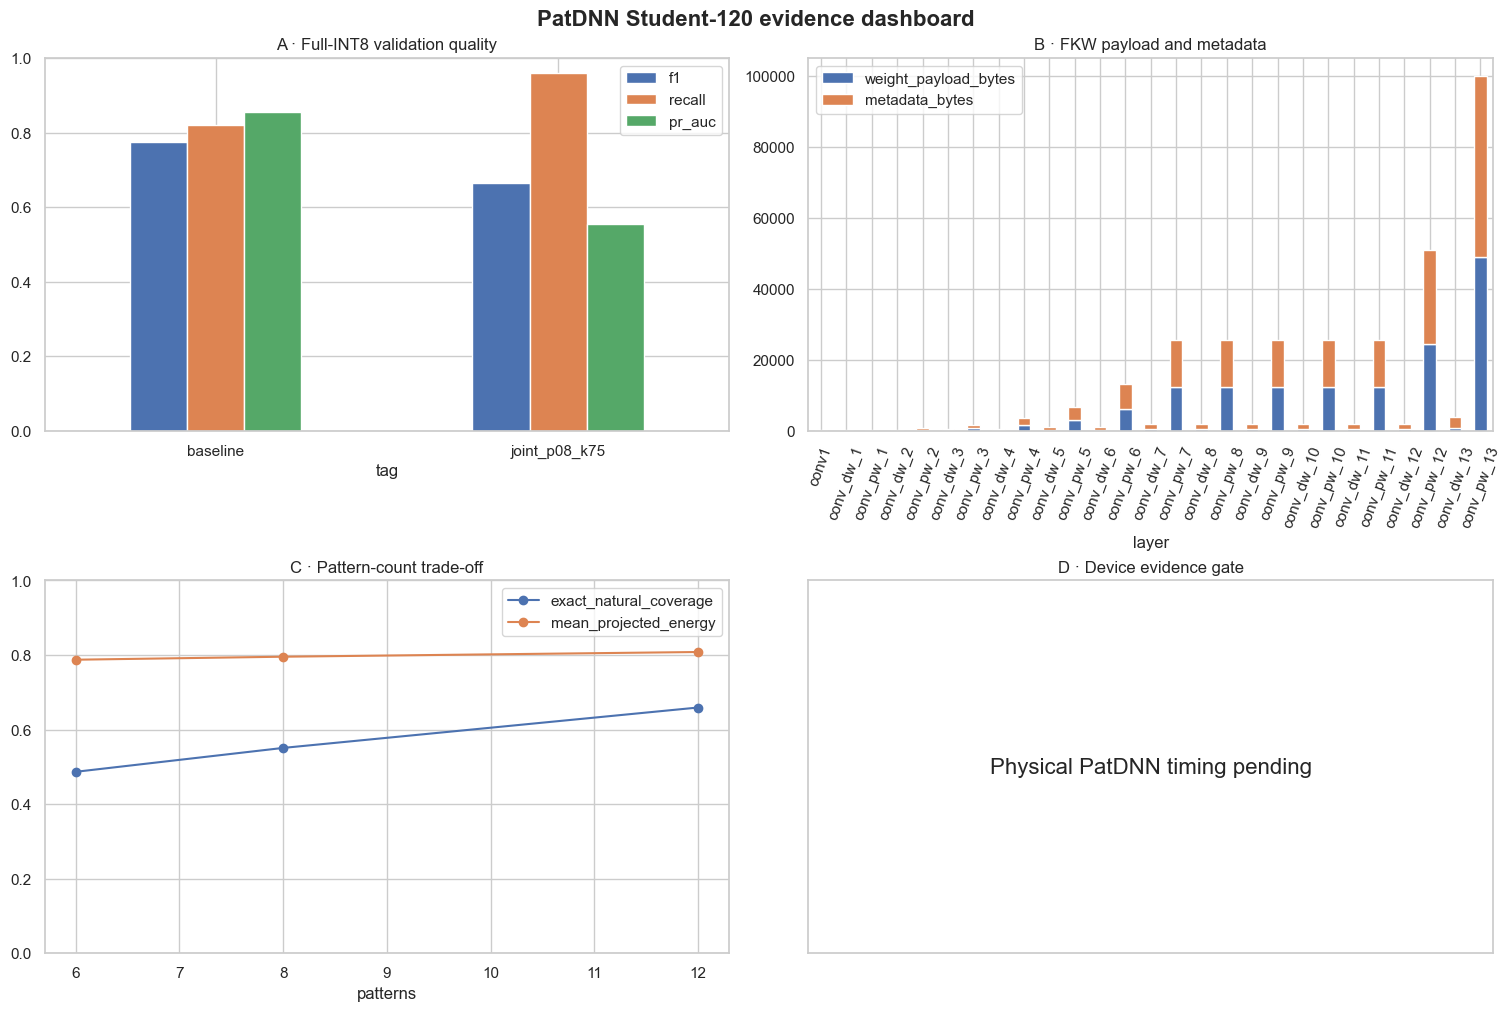

In [188]:
if len(int8_results):
    fig, axes = plt.subplots(2, 2, figsize=(15,10), constrained_layout=True)
    q = int8_results.set_index("tag").loc[["baseline",SELECTED_TAG]]
    q[["f1","recall","pr_auc"]].plot.bar(ax=axes[0,0], rot=0, ylim=(0,1), title="A · Full-INT8 validation quality")
    fkw_audit.set_index("layer")[["weight_payload_bytes","metadata_bytes"]].plot.bar(stacked=True, ax=axes[0,1], title="B · FKW payload and metadata")
    axes[0,1].tick_params(axis="x", rotation=70)
    library_coverage.set_index("patterns")[["exact_natural_coverage","mean_projected_energy"]].plot(ax=axes[1,0], marker="o", ylim=(0,1), title="C · Pattern-count trade-off")
    if len(device_results):
        device_results.plot.bar(x="board", y="mean_us", ax=axes[1,1], title="D · Physical generated-runtime latency", legend=False)
    else:
        axes[1,1].text(.5,.5,"Physical PatDNN timing pending",ha="center",va="center",fontsize=16)
        axes[1,1].set(title="D · Device evidence gate", xticks=[], yticks=[])
    fig.suptitle("PatDNN Student-120 evidence dashboard", fontsize=16, weight="bold")
    fig.savefig(FIGURE_DIR / "patdnn_evidence_dashboard.png", dpi=180, bbox_inches="tight"); plt.show()


## 35 · Write the machine-readable experiment manifest


In [189]:
manifest_payload = {
    "notebook":"optimization/pruning/pattern_based/14_patdnn_end_to_end_pattern_pruning.ipynb",
    "paper":"PatDNN, ASPLOS 2020", "paper_sha256":sha256_file(PAPER_PATH),
    "baseline":"Student-120 same_view_lambda0", "input":[1,120,120,3], "batch_size_device":1,
    "implemented":["natural pattern discovery","6/8/12 pattern libraries","joint Z/U/Y/V ADMM",
                   "pattern projection","connectivity projection","masked mapping and recovery","full-INT8 control",
                   "graph optimization inventory","layerwise representation","filter/kernel reorder","five-array FKW","kernel-level LRE analysis",
                   "filter-level reuse analysis","branch-free scalar C++ generation","genetic autotuning queue","device evidence gate"],
    "not_applicable":["OpenCL GPU backend on ESP32"],
    "frozen_hashes":frozen_hashes,
    "selected_tag":SELECTED_TAG if len(int8_results) else None,
    "physical_device_evidence":bool(len(device_results)),
}
(OUTPUT_DIR / "experiment_manifest.json").write_text(json.dumps(manifest_payload, indent=2)+"\n")
print(json.dumps(manifest_payload, indent=2))


{
  "notebook": "optimization/pruning/pattern_based/14_patdnn_end_to_end_pattern_pruning.ipynb",
  "paper": "PatDNN, ASPLOS 2020",
  "paper_sha256": "30457aee7d3c1742da21d363548cf6cbb092ff99058656ae04bb24ac1ccd3035",
  "baseline": "Student-120 same_view_lambda0",
  "input": [
    1,
    120,
    120,
    3
  ],
  "batch_size_device": 1,
  "implemented": [
    "natural pattern discovery",
    "6/8/12 pattern libraries",
    "joint Z/U/Y/V ADMM",
    "pattern projection",
    "connectivity projection",
    "masked mapping and recovery",
    "full-INT8 control",
    "graph optimization inventory",
    "layerwise representation",
    "filter/kernel reorder",
    "five-array FKW",
    "kernel-level LRE analysis",
    "filter-level reuse analysis",
    "branch-free scalar C++ generation",
    "genetic autotuning queue",
    "device evidence gate"
  ],
  "not_applicable": [
    "OpenCL GPU backend on ESP32"
  ],
  "frozen_hashes": {
    "configs/distillation_response_kd_alignment_120.yaml": "

## 36 · Interpretation checklist

After a complete run, answer each question with a table or figure—not intuition:

1. Did joint ADMM outperform fixed projection and either single constraint at equal recovery
   budget?
2. Which pattern count maximized INT8 validation quality, and how much compiler metadata did it
   cost?
3. How much of total Student-120 compute is actually covered by 3×3 patterns?
4. Did connectivity pruning of 1×1 layers save more arithmetic than its indices cost in flash and
   loads?
5. Did FKR reduce pattern switches and increase adjacent-filter reuse?
6. Did FKW reduce **total** bytes after metadata and alignment?
7. Are scalar, LRE, SIMD, host, and device outputs numerically equivalent?
8. Which optimization—pruning, FKR, LRE, or tuning—caused each measured latency reduction?
9. Did tensor-arena or activation SRAM change? If shapes are unchanged, explain why not.
10. Does the result pass both quality and physical-device gates on ESP32-CAM and ESP32-S3?


## 37 · Final status


In [190]:
status = {
    "training_complete": bool(len(candidate_results)),
    "int8_selection_complete": bool(len(int8_results)),
    "lr_fkw_codegen_complete": bool(len(int8_results)),
    "physical_device_profile_complete": bool(len(device_results)),
}
display(Markdown("\n".join(["**PatDNN workflow status**", ""] + [f"- {key.replace('_',' ')}: **{value}**" for key,value in status.items()])))
if not status["physical_device_profile_complete"]:
    print("Do not claim end-to-end PatDNN acceleration yet: physical generated-runtime ablations are still required.")


**PatDNN workflow status**

- training complete: **True**
- int8 selection complete: **True**
- lr fkw codegen complete: **True**
- physical device profile complete: **False**

Do not claim end-to-end PatDNN acceleration yet: physical generated-runtime ablations are still required.
